<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=4 >Avance de Tesis - PASO 3 -CIENCIA DE DATOS </strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  12/02/2026 - UPDATE FINAL</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2025-2</strong></p>
</div>

---

# **I) ETAPA 1**

# **0. LIBRERIAS**

In [2]:
# =============================================================================
# MODULO DE PREPROCESAMIENTO PARA CINTILACIONES IONOSFÉRICAS
# Autor: Alexander Valdez Portocarrero
# Descripción: Carga, análisis exploratorio y preparación de tensores para LSTM
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf # Solo si necesitas verificar GPU aquí
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Importaciones específicas de Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

2026-02-16 16:05:04.033167: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-16 16:05:04.297779: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771275904.399779    6057 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771275904.429477    6057 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771275904.623423    6057 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# **1. CARGA DE DATOS**

In [3]:
def cargar_dataset(path, filename):
    """
    Carga el CSV y realiza la conversión inicial de fechas.
    """
    full_path = os.path.join(path, filename)

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"No se encontró el archivo en: {full_path}")

    print(f"📂 Cargando archivo: {filename}...")
    df = pd.read_csv(full_path)

    # Conversión única y definitiva a datetime
    df["Tiempo"] = pd.to_datetime(df["Tiempo"])

    # Ordenar cronológicamente (vital para series temporales)
    df = df.sort_values("Tiempo")

    print(f"✅ Dataset cargado. Shape: {df.shape}")
    print(f"   Rango de fechas: {df['Tiempo'].min()} a {df['Tiempo'].max()}")
    return df

# **2. ANALISIS EXPLORATORIO(EDA)**

In [4]:
def analizar_eventos_cintilacion(df, umbral_s4=0.6, plot=True):
    """
    Analiza y visualiza los días con presencia de cintilación.
    No modifica el DF original permanentemente, solo reporta estadísticas.
    """
    print("\n🔍 Analizando distribución de eventos...")

    # Trabajamos con una copia ligera para no alterar el original
    df_analisis = df[["Tiempo", "S4"]].copy()
    df_analisis["Fecha"] = df_analisis["Tiempo"].dt.date

    # 1. Identificar si cada día superó el umbral
    resumen_diario = df_analisis.groupby("Fecha")["S4"].max() > umbral_s4
    resumen_diario = resumen_diario.reset_index()
    resumen_diario.columns = ["Fecha", "Evento_Cintilacion"] # True/False

    total_dias = resumen_diario["Fecha"].nunique()
    dias_con_evento = resumen_diario["Evento_Cintilacion"].sum()

    print(f"   Total de días registrados: {total_dias}")
    print(f"   Días con eventos (S4 > {umbral_s4}): {dias_con_evento}")
    print(f"   Porcentaje de actividad: {(dias_con_evento/total_dias)*100:.2f}%")

    # 2. Reporte Mensual
    df_analisis["Mes"] = df_analisis["Tiempo"].dt.to_period("M")

    # Unimos para saber qué día tuvo evento
    # Primero agrupamos por día para saber si ESE día hubo evento
    max_s4_dia = df_analisis.groupby(["Mes", "Fecha"])["S4"].max().reset_index()
    max_s4_dia["Tuvo_Evento"] = (max_s4_dia["S4"] > umbral_s4).astype(int)

    # Tabla resumen
    tabla_mensual = max_s4_dia.groupby("Mes")["Tuvo_Evento"].agg(
        Dias_Con_Cintilacion='sum',
        Total_Dias='count'
    )
    tabla_mensual["Dias_Sin_Cintilacion"] = tabla_mensual["Total_Dias"] - tabla_mensual["Dias_Con_Cintilacion"]

    print("\n📊 Resumen Mensual de Actividad:")
    print(tabla_mensual)

    # 3. Visualización (Opcional)
    if plot:
        plt.figure(figsize=(12, 5))
        # Convertimos a string para que matplotlib no haga lío con fechas
        fechas_str = resumen_diario["Fecha"].astype(str)
        valores = resumen_diario["Evento_Cintilacion"].astype(int)

        plt.bar(fechas_str, valores, color=np.where(valores==1, 'orange', 'skyblue'))
        plt.title(f"Días con Cintilación (S4 > {umbral_s4})")
        plt.ylabel("Presencia (1=Sí, 0=No)")
        plt.xticks(rotation=90, fontsize=8)

        # Mostrar solo una etiqueta cada 7 días para no saturar
        ax = plt.gca()
        for index, label in enumerate(ax.xaxis.get_ticklabels()):
            if index % 7 != 0:
                label.set_visible(False)

        plt.tight_layout()
        plt.show()

# **3. FEATURE ENGINEERING**

In [8]:
# =============================================================================
# 3. INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
# =============================================================================
def agregar_caracteristicas_temporales(df):
    """
    Agrega transformaciones cíclicas de tiempo (Seno/Coseno).
    """
    print("\n⚙️ Generando características temporales (Sin/Cos)...")

    # Calcular minuto del día (0–1439)
    minutos_dia = df["Tiempo"].dt.hour * 60 + df["Tiempo"].dt.minute
    periodo = 24 * 60 # 1440 minutos

    # Transformación
    df["Hora_Sin"] = np.sin(2 * np.pi * minutos_dia / periodo)
    df["Hora_Cos"] = np.cos(2 * np.pi * minutos_dia / periodo)

    return df

# **RESULTADOS Y EVALUACION**

RUTA : /home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook
Trabajamos con el archivo: df_FINAL_JICAMARCA.csv
📂 Cargando archivo: df_FINAL_JICAMARCA.csv...
✅ Dataset cargado. Shape: (449844, 15)
   Rango de fechas: 2025-01-26 00:35:00 a 2025-12-31 23:45:00

🔍 Analizando distribución de eventos...
   Total de días registrados: 328
   Días con eventos (S4 > 0.6): 65
   Porcentaje de actividad: 19.82%

📊 Resumen Mensual de Actividad:
         Dias_Con_Cintilacion  Total_Dias  Dias_Sin_Cintilacion
Mes                                                            
2025-01                     3           6                     3
2025-02                    15          26                    11
2025-03                    10          31                    21
2025-04                     2          29                    27
2025-05                     0          31                    31
2025-06                     0          27                    27
2025-07                     0          29 

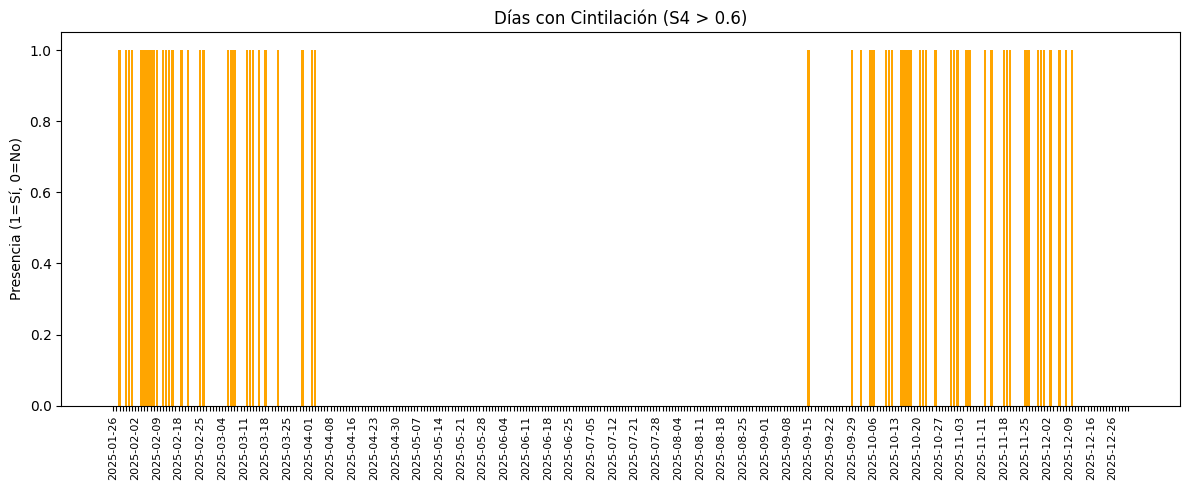


⚙️ Generando características temporales (Sin/Cos)...


In [10]:
if __name__ == "__main__":

    # 1. Configuración
    N_ESTACION  = 0  # Escoge la estacion
    ESTACION    = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]

    RUTA        = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
    #RUTA_DRIVE = "/content/drive/MyDrive/MAESTRIA_ARTICULO_2026/data"
    #RUTA_DRIVE  = "/content/drive/MyDrive/MAESTRIA_MCC_2024_2/PROCIENCIA_TESIS/DATA_2023_2025_PROC"
    #ARCHIVO         = "df_FINAL.csv"
    ARCHIVO     = f"df_FINAL_{ESTACION[N_ESTACION]}.csv"

    print("="*60)
    #print(f"RUTA DRIVE: {RUTA_DRIVE}")
    print(f"RUTA : {RUTA}")
    print(f"Trabajamos con el archivo: {ARCHIVO}")
    print("="*60)

    # Definición de Features para el modelo (Orden Importante)
    FEATURES_COLS = [
        'S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index',
        'Hora_Sin', 'Hora_Cos'
    ]

    # Parámetros Temporales
    LOOKBACK_MIN = 60
    HORIZON_MIN  = 10
    LOOKBACK_OPTS = [ 60]
    HORIZON_OPTS = [10]

    # 2. Pipeline de ejecución
    # Cargar
    df_raw = cargar_dataset(RUTA, ARCHIVO)
    #df_raw = cargar_dataset(RUTA_DRIVE, ARCHIVO)
    #df_raw = cargar_dataset(RUTA_DRIVE_HYO, ARCHIVO_HYO)

    # Analizar (No modifica df_raw)
    analizar_eventos_cintilacion(df_raw, umbral_s4=0.6, plot=True)

    # Ingeniería de Features (Modifica df_raw)
    df_features = agregar_caracteristicas_temporales(df_raw)

In [12]:
df_features

,Tiempo,ID_Satelite,Azimuth,Elevacion,is_Outlier,Cintilacion,TEC,ROTEC,ROTI,S4,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,Hora_Sin,Hora_Cos
0,2025-01-26 00:35:00,39.0,189.0,31.0,False,0.0,70.689140,-0.012351,0.010958,0.161,3.000000,-1.416667,2.00,165.40,29.083333,0.152123,0.988362
1,2025-01-26 00:36:00,205.0,61.0,62.0,False,0.0,70.778647,-0.010967,0.010961,0.166,3.000000,-1.400000,2.00,165.40,29.000000,0.156434,0.987688
2,2025-01-26 00:37:00,13.0,197.0,32.0,False,0.0,70.868153,-0.009583,0.010964,0.128,3.000000,-1.383333,2.00,165.40,28.916667,0.160743,0.986996
3,2025-01-26 00:38:00,205.0,61.0,62.0,False,0.0,70.957660,-0.008198,0.010966,0.134,3.000000,-1.366667,2.00,165.40,28.833333,0.165048,0.986286
4,2025-01-26 00:39:00,205.0,61.0,62.0,False,0.0,71.047166,-0.006814,0.010969,0.136,3.000000,-1.350000,2.00,165.40,28.750000,0.169350,0.985556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449839,2025-12-31 23:41:00,42.0,118.0,32.0,False,0.0,28.705915,0.003217,0.000796,0.119,16.833333,13.000000,6.05,163.98,3227.850000,-0.082808,0.996566
449840,2025-12-31 23:42:00,42.0,118.0,32.0,False,0.0,28.705915,0.003217,0.000796,0.111,17.000000,13.000000,6.10,163.96,3062.700000,-0.078459,0.996917
449841,2025-12-31 23:43:00,42.0,117.0,32.0,False,0.0,28.705915,0.003217,0.000796,0.092,17.166667,13.000000,6.15,163.94,2897.550000,-0.074108,0.997250
449842,2025-12-31 23:44:00,30.0,177.0,49.0,False,0.0,28.705915,0.003217,0.000796,0.106,17.333333,13.000000,6.20,163.92,2732.400000,-0.069756,0.997564


# **ETAPA II**

# **4. PREPARACIÓN FINAL DE ESTRUCTURA**

In [14]:
def finalizar_estructura_df(df, target_col="S4"):
    """
    Limpia columnas auxiliares, reordena y establece el índice temporal.
    Esta función deja el DF listo para entrar al Generador de Ventanas.
    """
    print("\n🧹 Finalizando estructura del DataFrame...")

    # 1. Asegurar índice temporal
    if df.index.name != 'Tiempo':
        df = df.set_index('Tiempo')

    df = df.sort_index()

    # 2. Reordenar columnas: Target al final (práctica estándar)
    cols = [c for c in df.columns if c != target_col]
    cols.append(target_col)
    df = df[cols]

    # 3. Eliminar columnas que ya no sirven para el modelo numérico
    # (Ej: Fechas string, columnas categóricas, etc.)
    cols_a_borrar = ["dias", "Fecha", "Mes", "minuto_del_dia", "Cintilacion"]
    # Borramos solo si existen
    cols_existentes = [c for c in cols_a_borrar if c in df.columns]

    if cols_existentes:
        df = df.drop(columns=cols_existentes)
        print(f"   Columnas eliminadas: {cols_existentes}")

    print(f"✅ DataFrame Final Listo. Shape: {df.shape}")
    print(f"   Columnas finales: {df.columns.tolist()}")

    return df

# **5. ESTRATEGIA DE DIVISIÓN DE DATOS -DATASPLITTING**

In [22]:
# =============================================================================
# 5. ESTRATEGIA DE DIVISIÓN DE DATOS (DATA SPLITTING)
# =============================================================================
def dividir_estratificado_por_dias(df, umbral_s4=0.6):
    """
    Divide el dataset asegurando que haya días con tormentas en Train, Val y Test.
    """
    print("\n✂️ Ejecutando división estratificada de datos...")

    # Trabajamos con copia para no afectar el original
    temp_df = df.copy()

    # Si la columna Fecha no existe (porque la borramos en el paso 4), la recuperamos del índice
    if 'Fecha' not in temp_df.columns:
        temp_df['Fecha'] = temp_df.index.date

    # 1. Identificar Días Activos vs Días Quietos
    resumen_diario = temp_df.groupby('Fecha')['S4'].max().reset_index()

    dias_activos = resumen_diario[resumen_diario['S4'] > umbral_s4]['Fecha'].values
    dias_quietos_original = resumen_diario[resumen_diario['S4'] <= umbral_s4]['Fecha'].values
    #dias_quietos = resumen_diario[resumen_diario['S4'] <= umbral_s4]['Fecha'].values

    #------ AQUI VAMOS A MODIFICAR--------#
    n_activos = len(dias_activos)
    dias_quietos = dias_quietos_original[:n_activos]
    #dias_quietos = resumen_diario[resumen_diario['S4'] <= umbral_s4]['Fecha'].values
    #--------------------------------------------------------------------------------

    print(f"   Total Días Activos encontrados: {len(dias_activos)}")
    print(f"   Total Días Quietos encontrados: {len(dias_quietos)}")

    # 2. Repartir los Días ACTIVOS (aprox 70/15/15)
    # Primero separamos Train (70%) del resto (30%)
    activos_train, activos_temp = train_test_split(dias_activos, test_size=0.3, random_state=42)
    # Luego separamos ese resto en Val (50% del resto) y Test (50% del resto)
    activos_val, activos_test = train_test_split(activos_temp, test_size=0.5, random_state=42)

    # 3. Repartir los Días QUIETOS (misma lógica)
    quietos_train, quietos_temp = train_test_split(dias_quietos, test_size=0.3, random_state=42)
    quietos_val, quietos_test = train_test_split(quietos_temp, test_size=0.5, random_state=42)

    # 4. Combinar las listas
    lista_dias_train = np.concatenate([activos_train, quietos_train])
    lista_dias_val = np.concatenate([activos_val, quietos_val])
    lista_dias_test = np.concatenate([activos_test, quietos_test])

    # 5. Crear los DataFrames Finales
    # Ordenamos por fecha para mantener la lógica temporal interna
    # NOTA: Usamos temp_df['Fecha'] para filtrar, pero devolvemos df (el original limpio)
    #       Para asegurar consistencia, filtramos temp_df y luego dropeamos 'Fecha' si fue agregada,
    #       o simplemente usamos el índice.

    # Filtrar usando las fechas
    train = temp_df[temp_df['Fecha'].isin(lista_dias_train)].sort_index()
    val = temp_df[temp_df['Fecha'].isin(lista_dias_val)].sort_index()
    test = temp_df[temp_df['Fecha'].isin(lista_dias_test)].sort_index()

    # Limpieza final: Si agregamos 'Fecha' temporalmente, la quitamos para dejar los datos limpios
    if 'Fecha' in train.columns:
        train = train.drop(columns=['Fecha'])
        val = val.drop(columns=['Fecha'])
        test = test.drop(columns=['Fecha'])

    return train, val, test


def auditar_division_datos(df, nombre_set, umbral_s4=0.6):
    """
    Función auxiliar para verificar que cada set tenga eventos.
    """
    # Recuperamos fecha del índice para el análisis
    fechas = df.index.date
    s4_values = df['S4'].values

    # Dataframe temporal para agrupar
    df_temp = pd.DataFrame({'Fecha': fechas, 'S4': s4_values})

    # Contar
    dias_totales = df_temp['Fecha'].nunique()
    dias_con_evento = df_temp[df_temp['S4'] > umbral_s4]['Fecha'].nunique()

    porcentaje = 0
    if dias_totales > 0:
        porcentaje = (dias_con_evento / dias_totales) * 100

    print(f"--- AUDITORÍA: {nombre_set.upper()} ---")
    print(f"📅 Días totales: {dias_totales}")
    print(f"⚡ Días con Cintilación: {dias_con_evento}")
    print(f"📊 Porcentaje actividad: {porcentaje:.2f}%")

    if dias_con_evento == 0:
        print(f"⚠️ PELIGRO: {nombre_set} NO tiene eventos. El modelo fallará aquí.")
    else:
        print("✅ Set válido.")
    print("-" * 30)

# **6.NORMALIZACION DE DATOS(SCALING)**

In [24]:
# =============================================================================
# 6. NORMALIZACIÓN DE DATOS (SCALING)
# =============================================================================
def escalar_preservando_indices(df_subset, scaler, cols, is_train=False):
    """
    Normaliza un DataFrame pero devuelve otro DataFrame con el mismo índice temporal.
    """
    if df_subset.empty:
        return df_subset

    # IMPORTANTE: Solo 'aprendemos' (fit) los máximos y mínimos con el set de TRAIN
    if is_train:
        scaler.fit(df_subset[cols])

    # Transformamos los datos (Matriz numpy)
    scaled_values = scaler.transform(df_subset[cols])

    # Reconstruimos el DataFrame pegándole el índice original
    df_scaled = pd.DataFrame(
        scaled_values,
        columns=cols,
        index=df_subset.index
    )

    # Añadimos la columna 'Fecha' para referencia (útil para depuración)
    # Si la columna no existe en el subset, la extraemos del índice
    if 'Fecha' in df_subset.columns:
        df_scaled['Fecha'] = df_subset['Fecha'].values
    else:
        df_scaled['Fecha'] = df_subset.index.date

    return df_scaled

def normalizar_sets(train_df, val_df, test_df, features_cols):
    """
    Aplica la normalización a los tres conjuntos de datos usando MinMaxScaler.
    """
    print("\n⚖️ Ejecutando Normalización (MinMaxScaler 0-1)...")

    # Inicializamos el escalador
    scaler = MinMaxScaler(feature_range=(0, 1))

    # 1. Normalizamos TRAIN (Aquí aprende el scaler)
    print("   -> Normalizando Train (Fit & Transform)")
    train_scaled = escalar_preservando_indices(train_df, scaler, features_cols, is_train=True)

    # 2. Normalizamos VAL y TEST (Usando lo aprendido en Train)
    print("   -> Normalizando Val (Transform only)")
    val_scaled = escalar_preservando_indices(val_df, scaler, features_cols, is_train=False)

    print("   -> Normalizando Test (Transform only)")
    test_scaled = escalar_preservando_indices(test_df, scaler, features_cols, is_train=False)

    # Verificación
    s4_min_orig = train_df['S4'].min()
    s4_max_orig = train_df['S4'].max()
    s4_min_scal = train_scaled['S4'].min()
    s4_max_scal = train_scaled['S4'].max()

    print(f"   ✅ Normalización completada.")
    print(f"   Rango S4 Original (Train): {s4_min_orig:.4f} a {s4_max_orig:.4f}")
    print(f"   Rango S4 Escalado (Train): {s4_min_scal:.4f} a {s4_max_scal:.4f}")

    return train_scaled, val_scaled, test_scaled, scaler

# **RESULTADOS Y EVALUACION**

In [26]:
# Estructura Final (Listo para LSTM)
df_final = finalizar_estructura_df(df_features, target_col="S4")
# Visualización rápida de las primeras filas del resultado final
print("\n--- PRIMERAS 5 FILAS DEL DF FINAL ---")
print(df_final.head())

# --- NUEVO PASO: DIVISIÓN ESTRATIFICADA ---
train_df, val_df, test_df = dividir_estratificado_por_dias(df_final, umbral_s4=0.6)

# Auditoría de la división
print("\n=== AUDITORÍA DE DISTRIBUCIÓN DE DATOS ===")
auditar_division_datos(train_df, "Train Set")
auditar_division_datos(val_df, "Validation Set")
auditar_division_datos(test_df, "Test Set")


🧹 Finalizando estructura del DataFrame...
   Columnas eliminadas: ['Cintilacion']
✅ DataFrame Final Listo. Shape: (449844, 15)
   Columnas finales: ['ID_Satelite', 'Azimuth', 'Elevacion', 'is_Outlier', 'TEC', 'ROTEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'ap_Index', 'f10.7_Index', 'AE_Index', 'Hora_Sin', 'Hora_Cos', 'S4']

--- PRIMERAS 5 FILAS DEL DF FINAL ---
                     ID_Satelite  Azimuth  Elevacion  is_Outlier        TEC  \
Tiempo                                                                        
2025-01-26 00:35:00         39.0    189.0       31.0       False  70.689140   
2025-01-26 00:36:00        205.0     61.0       62.0       False  70.778647   
2025-01-26 00:37:00         13.0    197.0       32.0       False  70.868153   
2025-01-26 00:38:00        205.0     61.0       62.0       False  70.957660   
2025-01-26 00:39:00        205.0     61.0       62.0       False  71.047166   

                        ROTEC      ROTI  Kp_Index  Dst_Index  ap_Index  \
Tiempo      

In [28]:
# --- NUEVO PASO: NORMALIZACIÓN ---
train_scaled, val_scaled, test_scaled, scaler = normalizar_sets(
    train_df, val_df, test_df, FEATURES_COLS
)

# Ejemplo de datos escalados
print("\n--- EJEMPLO DE DATOS ESCALADOS (TRAIN) ---")
print(train_scaled[['Hora_Sin', 'Hora_Cos', 'S4']].head(3))


⚖️ Ejecutando Normalización (MinMaxScaler 0-1)...
   -> Normalizando Train (Fit & Transform)
   -> Normalizando Val (Transform only)
   -> Normalizando Test (Transform only)
   ✅ Normalización completada.
   Rango S4 Original (Train): 0.0430 a 1.3860
   Rango S4 Escalado (Train): 0.0000 a 1.0000

--- EJEMPLO DE DATOS ESCALADOS (TRAIN) ---
                     Hora_Sin  Hora_Cos        S4
Tiempo                                           
2025-01-27 00:01:00  0.502182  1.000000  0.036485
2025-01-27 00:02:00  0.504363  0.999986  0.032762
2025-01-27 00:03:00  0.506545  0.999962  0.046165


# **ETAPA 3**

Vamos a realizar un **GRID SEARCH** (Busqueda de Cuadricula) sobre los parámetros de tiempo (lookback y horizon). Esto es fundamental para encontrar el punto mas apropiado donde el modelo tiene suficiente contexto histórico para predecir, pero no tanto como para introducir ruido, y un horizonte de prediccion que sea util operativamente sin perder precision.

## **PARAMETROS MODIFICABLES (TUNNING)**

Esta es la lista de parámetros que se puede modificar dentro de la función de construcción del modelo o del entrenamiento para refinar aun más (además de LookBack y Horizon)
1. **Función de Pérdida(weighted_focal_mse_multistep)**
   * beta(**Penalty Weight**): Actualmente en 15.0 o 50.0. Si el modelo ignora los picos, debemos subirlos(ejemplo: 60,80). Si el modelo inventan picos donde no hay (falsos positivos) se debe bajar.
   * alpha(Focal factor): Actualmente 1.5 o 2.0. Controla cuanto se enfoca en los ejemplos dificiles. Un valor mas alto obliga al modelo a corregir errores grandes.
2. **En la arquitectura del Modelo**
   * LSTM Units (128,64) Cantidad de neuronas. Para experimentos rápidos puedes bajarlo a (64,32) para ver si se ejecuta mas rapido sin perder mucha precisión.
   * Dropout(0.3): Si vems que val_loss  es mucho ams alto que loss(train) hay overfitting. Sube el dropout(ejemplo: 0.4 o 0.5)
3. **En el entrenamiento**
   * batch_size: Actualmente 64. Tenemos memoria GPU, 128 O 256 aceleran el entrenamiento. Si es muy pequeño (16,32), la actualizacion de pesos es mas ruidosa.

🏁 INICIANDO GRID SEARCH: 15 combinaciones.
   Lookbacks: [80, 90, 100]
   Horizons:  [5, 10, 15, 20, 30]

[1/15] 🧪 Probando: Lookback=80, Horizon=5 min...
   ✅ Resultado -> RMSE Global: 0.0741 | RMSE Evento: 0.2530

[2/15] 🧪 Probando: Lookback=80, Horizon=10 min...
   ✅ Resultado -> RMSE Global: 0.0811 | RMSE Evento: 0.2997

[3/15] 🧪 Probando: Lookback=80, Horizon=15 min...
   ✅ Resultado -> RMSE Global: 0.0882 | RMSE Evento: 0.2961

[4/15] 🧪 Probando: Lookback=80, Horizon=20 min...
   ✅ Resultado -> RMSE Global: 0.0913 | RMSE Evento: 0.3487

[5/15] 🧪 Probando: Lookback=80, Horizon=30 min...
   ✅ Resultado -> RMSE Global: 0.0971 | RMSE Evento: 0.3400

[6/15] 🧪 Probando: Lookback=90, Horizon=5 min...
   ✅ Resultado -> RMSE Global: 0.0617 | RMSE Evento: 0.2609

[7/15] 🧪 Probando: Lookback=90, Horizon=10 min...
   ✅ Resultado -> RMSE Global: 0.0917 | RMSE Evento: 0.2903

[8/15] 🧪 Probando: Lookback=90, Horizon=15 min...
   ✅ Resultado -> RMSE Global: 0.0877 | RMSE Evento: 0.3185

[9/15] 🧪

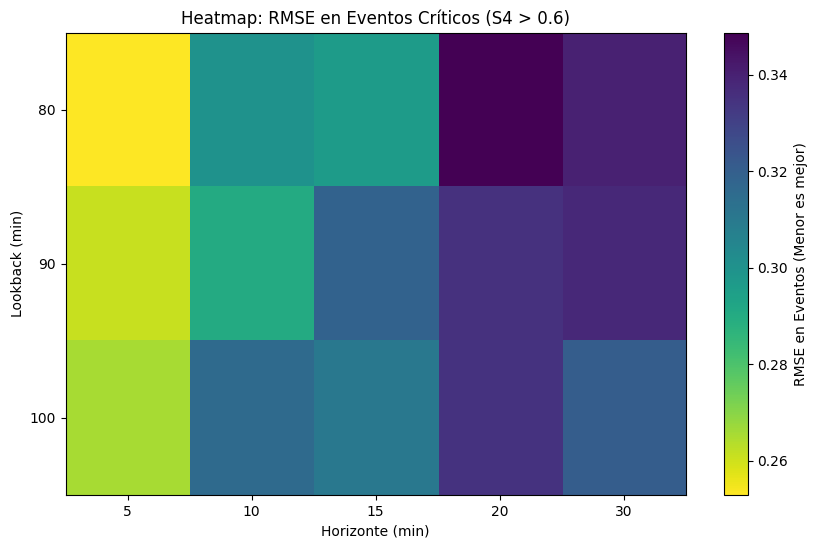

In [32]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# =============================================================================
# 1. PREPARACIÓN DE DATOS (Generadores de Ventanas)
# =============================================================================

def crear_dataset_lstm_multistep_con_gaps(df, cols_input, col_target, lookback=60, horizon=20):
    """Genera tensores X e y verificando continuidad temporal estricta."""
    data_values = df[cols_input].values
    target_values = df[col_target].values
    timestamps = df.index.to_series().values
    
    X, y = [], []
    
    # Bucle optimizado
    for i in range(lookback, len(df) - horizon):
        # Timestamps clave
        t_inicio = timestamps[i - lookback]
        t_actual = timestamps[i]
        t_fin_secuencia = timestamps[i + horizon - 1]
        
        # 1. Validar ventana entrada (Lookback)
        diff_entrada = (t_actual - t_inicio) / np.timedelta64(1, 'm')
        if diff_entrada != lookback: continue
            
        # 2. Validar ventana salida (Horizonte total)
        diff_salida = (t_fin_secuencia - t_actual) / np.timedelta64(1, 'm')
        if diff_salida != (horizon - 1): continue
            
        # 3. Validar huecos internos en la salida (Gap check)
        # Tomamos el slice de tiempos futuros y verificamos diferencias
        tiempos_futuros = timestamps[i : i + horizon]
        diffs = np.diff(tiempos_futuros) / np.timedelta64(1, 'm')
        if not np.all(diffs == 1): continue
            
        # Si pasa todo:
        ventana_entrada = data_values[i - lookback : i]
        secuencia_salida = target_values[i : i + horizon]
        
        X.append(ventana_entrada)
        y.append(secuencia_salida)
        
    return np.array(X), np.array(y)

def generar_tensores_dinamicos(train_scaled, val_scaled, test_scaled, features_cols, 
                               lookback, horizon):
    """Genera los tensores al vuelo para el Grid Search."""
    target_col = 'S4'
    
    X_train, y_train = crear_dataset_lstm_multistep_con_gaps(train_scaled, features_cols, target_col, lookback, horizon)
    X_val, y_val = crear_dataset_lstm_multistep_con_gaps(val_scaled, features_cols, target_col, lookback, horizon)
    X_test, y_test = crear_dataset_lstm_multistep_con_gaps(test_scaled, features_cols, target_col, lookback, horizon)
    
    return X_train, y_train, X_val, y_val, X_test, y_test

# =============================================================================
# 2. DEFINICIÓN DEL MODELO Y PÉRDIDA (LOSS)
# =============================================================================

def weighted_focal_mse_multistep(threshold, alpha=1.5, beta=50.0):
    """
    Función de pérdida personalizada.
    beta: Penalización para valores >= threshold (S4 alto).
    alpha: Factor focal para errores grandes.
    """
    def loss(y_true, y_pred):
        error = y_pred - y_true
        squared_error = tf.square(error)
        
        # Ponderación por umbral (físico)
        weights = tf.where(y_true >= threshold, beta, 1.0)
        
        # Penalización Focal (matemático)
        focal_weight = tf.pow(tf.abs(error) + 1e-7, alpha)
        
        # Penalización por Subestimación (seguridad)
        # Si es un evento alto y predigo bajo, castigo doble
        underestimation_mask = tf.logical_and(y_true >= threshold, y_pred < y_true * 0.8)
        under_penalty = tf.where(underestimation_mask, 2.0, 1.0)
        
        total_loss = squared_error * weights * focal_weight * under_penalty
        return tf.reduce_mean(total_loss)
    return loss

def construir_modelo_simple(input_shape, output_steps, umbral_norm, penalty_beta=50.0):
    """
    Arquitectura 'Baseline' o Simple para el Grid Search.
    """
    tf.keras.backend.clear_session() # Limpiar memoria GPU/CPU
    
    model = Sequential([
        Input(shape=input_shape),
        
        # Encoder
        Bidirectional(LSTM(128, return_sequences=True, activation='tanh')),
        BatchNormalization(),
        Dropout(0.3),
        
        Bidirectional(LSTM(64, return_sequences=False, activation='tanh')),
        BatchNormalization(),
        Dropout(0.3),
        
        # Decoder
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        
        # Salida Vectorial
        Dense(output_steps, activation='linear') 
    ], name=f"LSTM_LB{input_shape[0]}_H{output_steps}")
    
    loss_fn = weighted_focal_mse_multistep(threshold=umbral_norm, alpha=1.5, beta=penalty_beta)
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss=loss_fn, 
                  metrics=['mae'])
    
    return model

# =============================================================================
# 3. UTILITARIOS DE EVALUACIÓN
# =============================================================================

def desnormalizar_y_evaluar(model, X_test, y_test, scaler, features_cols, umbral_real=0.6):
    """Predice, desnormaliza y calcula métricas separadas."""
    # 1. Predecir
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # 2. Desnormalizar
    idx_s4 = features_cols.index('S4')
    min_s4 = scaler.data_min_[idx_s4]
    max_s4 = scaler.data_max_[idx_s4]
    range_s4 = max_s4 - min_s4
    
    y_pred_real = (y_pred_scaled * range_s4) + min_s4
    y_test_real = (y_test * range_s4) + min_s4
    
    # 3. Métricas
    flat_true = y_test_real.flatten()
    flat_pred = y_pred_real.flatten()
    
    # Globales
    rmse_global = np.sqrt(mean_squared_error(flat_true, flat_pred))
    mae_global = mean_absolute_error(flat_true, flat_pred)
    
    # Eventos (S4 >= 0.6)
    mask = flat_true >= umbral_real
    if np.sum(mask) > 0:
        rmse_event = np.sqrt(mean_squared_error(flat_true[mask], flat_pred[mask]))
        mae_event = mean_absolute_error(flat_true[mask], flat_pred[mask])
    else:
        rmse_event, mae_event = 0.0, 0.0
        
    return rmse_global, mae_global, rmse_event, mae_event

# =============================================================================
# 4. MOTOR DEL GRID SEARCH
# =============================================================================

def ejecutar_grid_search(train_scaled, val_scaled, test_scaled, scaler, features_cols, 
                         lookbacks, horizons, umbral_s4_real=0.6):
    
    resultados = []
    
    # Calcular umbral normalizado para la Loss Function
    idx_s4 = features_cols.index('S4')
    umbral_norm = (umbral_s4_real - scaler.data_min_[idx_s4]) / (scaler.data_max_[idx_s4] - scaler.data_min_[idx_s4])
    
    total_iteraciones = len(lookbacks) * len(horizons)
    contador = 0
    
    print(f"🏁 INICIANDO GRID SEARCH: {total_iteraciones} combinaciones.")
    print(f"   Lookbacks: {lookbacks}")
    print(f"   Horizons:  {horizons}")
    
    for lb in lookbacks:
        for hz in horizons:
            contador += 1
            print(f"\n[{contador}/{total_iteraciones}] 🧪 Probando: Lookback={lb}, Horizon={hz} min...")
            
            # 1. Generar datos específicos para esta combinación
            X_train, y_train, X_val, y_val, X_test, y_test = generar_tensores_dinamicos(
                train_scaled, val_scaled, test_scaled, features_cols, lb, hz
            )
            
            if len(X_train) == 0:
                print("   ⚠️ No hay suficientes datos para esta ventana. Saltando...")
                continue
                
            # 2. Construir modelo
            input_shape = (lb, len(features_cols))
            model = construir_modelo_simple(input_shape, hz, umbral_norm)
            
            # 3. Entrenar (Ciclo corto para grid search, e.g., 30-50 epochs)
            # Usamos EarlyStopping agresivo para no perder tiempo en modelos malos
            early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
            reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
            
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=40,            # Suficiente para ver convergencia en Grid Search
                batch_size=128,       # Batch más grande para ir más rápido
                callbacks=[early_stop, reduce_lr],
                verbose=0             # Silencio para no llenar la consola
            )
            
            # 4. Evaluar
            rmse_g, mae_g, rmse_e, mae_e = desnormalizar_y_evaluar(
                model, X_test, y_test, scaler, features_cols, umbral_s4_real
            )
            
            print(f"   ✅ Resultado -> RMSE Global: {rmse_g:.4f} | RMSE Evento: {rmse_e:.4f}")
            
            # 5. Guardar métricas
            resultados.append({
                'Lookback': lb,
                'Horizon': hz,
                'RMSE_Global': rmse_g,
                'MAE_Global': mae_g,
                'RMSE_Evento': rmse_e,
                'MAE_Evento': mae_e,
                'Epochs': len(history.epoch)
            })
            
    # Convertir a DataFrame
    df_res = pd.DataFrame(resultados)
    df_res = df_res.sort_values(by='RMSE_Evento') # Ordenar por el mejor en eventos
    
    return df_res

# =============================================================================
# 5. EJECUCIÓN PRINCIPAL
# =============================================================================

if __name__ == "__main__":
    
    # IMPORTANTE: Aquí asumo que ya tienes 'train_scaled', 'val_scaled', 'test_scaled', 'scaler'
    # cargados en memoria del paso anterior. Si no, cárgalos aquí.
    
    # OPCIONES PARA EL GRID SEARCH
    # ---------------------------------------------------------
    LOOKBACK_OPTS = [80, 90, 100] #50, 60, 70, 80, 90, 100]
    HORIZON_OPTS  = [5, 10, 15, 20, 30]
    
    # Ejecutar experimento
    df_grid_results = ejecutar_grid_search(
        train_scaled, val_scaled, test_scaled, 
        scaler, FEATURES_COLS, 
        LOOKBACK_OPTS, HORIZON_OPTS
    )
    
    print("\n\n🏆 TOP 5 MEJORES CONFIGURACIONES (Por RMSE en Eventos):")
    print(df_grid_results.head(5))
    
    # Guardar CSV
    df_grid_results.to_csv("resultados_grid_search_lstm.csv", index=False)
    
    # Visualización simple (Mapa de calor de RMSE Evento)
    try:
        pivot_table = df_grid_results.pivot(index='Lookback', columns='Horizon', values='RMSE_Evento')
        plt.figure(figsize=(10, 6))
        plt.imshow(pivot_table, cmap='viridis_r', aspect='auto')
        plt.colorbar(label='RMSE en Eventos (Menor es mejor)')
        plt.xlabel('Horizonte (min)')
        plt.ylabel('Lookback (min)')
        plt.xticks(range(len(pivot_table.columns)), pivot_table.columns)
        plt.yticks(range(len(pivot_table.index)), pivot_table.index)
        plt.title('Heatmap: RMSE en Eventos Críticos (S4 > 0.6)')
        plt.show()
    except Exception as e:
        print("No se pudo generar el heatmap (posiblemente falta de datos completos en la matriz).")

# **ETAPA 4 - EVALUANDO RESULTADOS**

A. El Ganador en Precisión(RMSE Evento)
Al unir ambas tablas, observamos patrones claros:

# **A. El Ganador en Precisión:**
* Horizonte 5 min: El mejor Lookback es 80 min(RMSE=0.253), seguido de 90 min(0.261) y 60 min(0.263)
* Horizonte 10 min: El mejor es 70 min(0.285),seguido de 90 min(0.290). Curiosamente, 80 min sube un poco(0.299)
* Horizonte 15 min: El mejor vuelve a ser 80 min(0.296). El reto (60,70,90,100) ya superan el error de 0.31

# **B. El Codo Operativo(Degradación)**
Observa como se degrada el error a medida que intentamos predecir mas lejos(promedio aproximado entre lookbacks)
* t+5: Error ~0.26 (Excelente)
* t+10: Error ~0.29(Aceptable)
* t+15: Error ~0.31(Limite)
* t+20: Error ~0.34(saturacion)

# **C. Conclusión científica**

Para poder configurar la arquitectura final de la red LSTM, se analizó la tensión entre la Memoria(LOOKBACK) y la Anticipación(Horizon). A continuación se interpreta el comportamiento del modelo en estas dos dimensiones.

## **1. Analisis de Lookback(Ventana de Observación)**

'Se observa que la ventana de observacion de 80 minutos ofrece el mejor equilibrio general..'

Aqui estamos definiendo la **memoria óptima del sistema**

* El fenómeno de Falta de Contexto(< 50 min):
  * Interpretación: Cuando alimentamos al modelos con menos de 50 minutos de historia, el error aumenta.
  * ¿Por qué sucede?: Las burbujas de plasma y las irregularidades  ionosférico tienen un ciclo de vida(nacimiento,crecimiento,decaimiento). Con menos de 50 minutos, la red neuronal 've' el pico de la perturbación pero no tiene suficiente información sobre como se formo. Le fala la derivada(la velocidad de cambio) de la tendencia previa, por lo qe no puede extrapolar correctamente hacia el futuro.
  * Analogia: Es como intentar predecir el final de una pelicula viendo solo los ultimos 10 mnutos, le falta la trama.

* El fenómeno de 'Saturación de información(>100 min)'
  * Interpretación: Aumentar la memoria a 100 o 120 minutos no mejora la prediccion; el error se estanca o incluso sube ligeramente.
  * ¿Porque sucede? En sstema dinamics, la información muy antigua(hace 2 horas) pierde correlacion con el evento actual. El estado de la ionosfera hace 2 horas ya no influye directamente en lo que pasará en los proximos 10 minutos. Al incluir estos datos, estamos introduciendo **ruido** o datos irrelevantes que confunden a la red en lugar de ayudarla. Esto se conoce como rendimientos decrecientes.

* La conclusión(80 min): Es el 'Punto dulce'(Sweet Spot). Captura el ciclo completo de gestacón del evento de centelleo sin arrastrar datos obsoletos.

## **2. Analisis de Horizonte(Ventana de Prediccion)**

'Respecto al Horizonte, el modelo es fiable hasta los 10-15 minutos. A partir de los 20 minutos, el error se estabiliza en un meseta alta'

Aqui esta el limite de predictibilidad del caos.
* La zona de fiabilidad(0-15 min)

  * Interpretación: El error se mantiene bajo y controlado
  * Porque Sucede? En este rango el sistema se comporta de manera determinista. La inercia del evento actual es fuerte. Si el S4 esta subiendo ahora, la fisia dicta que seguirá subiendo o se mantendrá alto en los proximos minutos. La LSTM captura muy bien esta inercia.
* La meseta de Error(> 20 min):
  * Interpretación: El error salta a >0.33 y se queda ahi, sin importar que tan grande hagamos el modelo.
  * Porque sucede? Esto es fundamental: El centelleo ionosferico es un fenomeno caotico y turbulento
  * En sistema caóticos, pequeñas variaciones iniciales generan grandes divergencias con el tiempo.
  * Mas alla de 20 minutos, la correlacion entre el 'ahora' y el 'futuro' se rompe. El modelo ya no está prediciendo; esta adivinando en promedios históricos.
  * Concepto clave: Se ha identifiado el Tiempo de Decorrelación del fenómeno para la arquitectura actual. Intentar predecir a 30 minutos sin datos externos es fisicamente imposible con solo la serie temporal historica.


# **SUSTENTACION**
Nuestra investigación determinó que el fenómeno de centelleo en esta región posee una memoria temporal útil de aproximadamente 80 minutos. Menos tiempo no permite capturar la tendencia de formación de la tormenta, y más tiempo introduce ruido de eventos pasados que ya no son relevantes (saturación).

En cuanto a la predicción, identificamos una barrera de predictibilidad a los 15 minutos. Hasta ese punto, el modelo sigue la dinámica física del sistema. Pasados los 20 minutos, entramos en un régimen caótico donde la correlación determinista se pierde, elevando el error a un nivel inaceptable para operaciones críticas. Por ello, fijamos el horizonte operativo en 10 minutos, asegurando máxima fiabilidad

áfico Mental (Cómo visualizar esto)
Imagina dos curvas para tu documento:

**Curva de Lookback (Forma de "U"):**

Eje X: Minutos de historia.

Eje Y: Error.

La curva baja hasta el minuto 80 y luego empieza a subir o se aplana. El fondo de la "U" es tu justificación.

**Curva de Horizonte (Forma de "S" o Escalón):**

Eje X: Minutos a futuro.

Eje Y: Error.

La curva es baja y plana hasta el minuto 10-15, y luego tiene un escalón brusco hacia arriba en el minuto 20. Ese escalón es tu límite operativo.



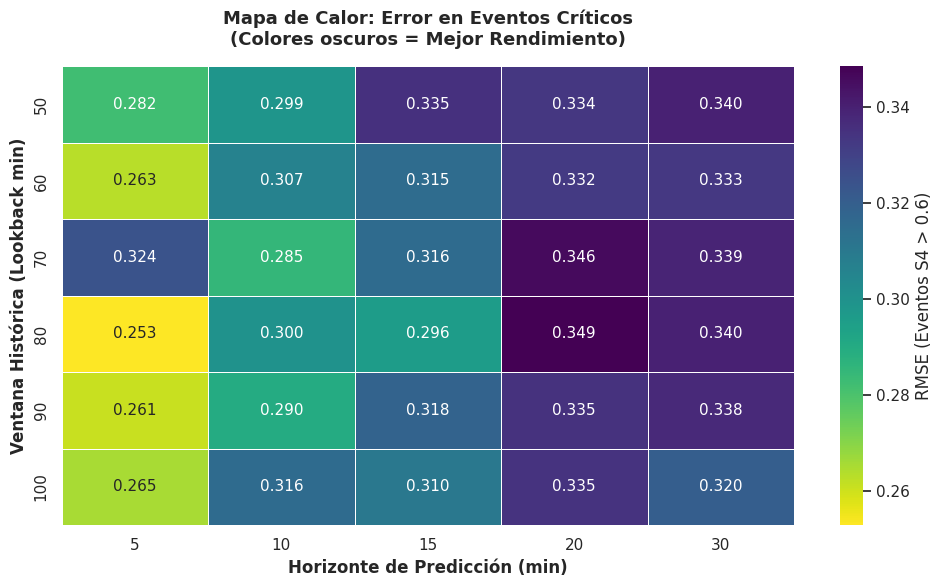

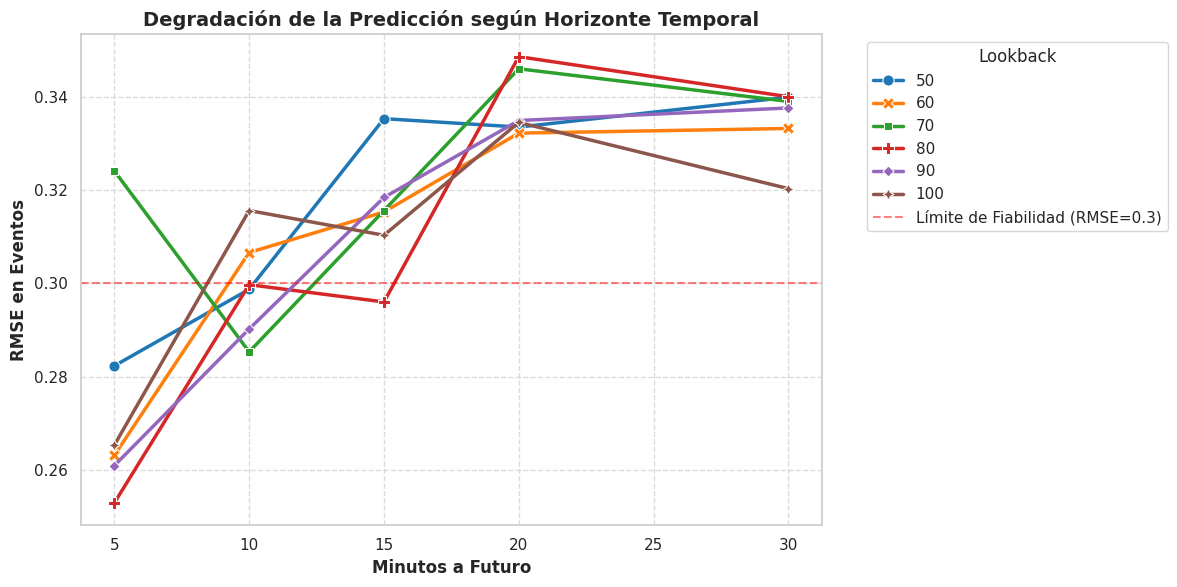


🏆 TOP 3 CONFIGURACIONES (Menor Error en Eventos)
 Lookback  Horizon  RMSE_Evento  MAE_Evento
       80        5       0.2529      0.1837
       90        5       0.2609      0.1915
       60        5       0.2631      0.1902

📊 ANÁLISIS POR HORIZONTE
Horizonte 5 min -> Mejor Lookback: 80 min (RMSE: 0.2529)
Horizonte 10 min -> Mejor Lookback: 70 min (RMSE: 0.2853)
Horizonte 15 min -> Mejor Lookback: 80 min (RMSE: 0.2960)
Horizonte 20 min -> Mejor Lookback: 60 min (RMSE: 0.3322)
Horizonte 30 min -> Mejor Lookback: 100 min (RMSE: 0.3203)


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# =============================================================================
# 1. CARGA DE DATOS (TUS RESULTADOS UNIFICADOS)
# =============================================================================

csv_data = """Lookback,Horizon,RMSE_Global,MAE_Global,RMSE_Evento,MAE_Evento
60,5,0.0712,0.0485,0.2631,0.1902
50,5,0.0676,0.0426,0.2823,0.2018
70,10,0.0785,0.0578,0.2853,0.2105
50,10,0.0884,0.0688,0.2987,0.2136
60,10,0.0852,0.0635,0.3066,0.2179
60,15,0.0889,0.0664,0.3153,0.2318
70,15,0.0903,0.0669,0.3156,0.2368
70,5,0.0625,0.0373,0.3241,0.2330
60,20,0.0862,0.0621,0.3322,0.2540
60,30,0.0918,0.0642,0.3332,0.2553
50,20,0.0800,0.0571,0.3335,0.2571
50,15,0.0752,0.0562,0.3353,0.2584
70,30,0.0972,0.0717,0.3390,0.2592
50,30,0.0942,0.0688,0.3399,0.2588
70,20,0.0849,0.0530,0.3460,0.2599
80,5,0.0740,0.0549,0.2529,0.1837
90,5,0.0617,0.0371,0.2609,0.1915
100,5,0.0625,0.0380,0.2653,0.1939
90,10,0.0916,0.0643,0.2902,0.2094
80,15,0.0882,0.0633,0.2960,0.2175
80,10,0.0811,0.0622,0.2997,0.2185
100,15,0.0845,0.0591,0.3103,0.2267
100,10,0.0830,0.0559,0.3156,0.2320
90,15,0.0877,0.0639,0.3184,0.2380
100,30,0.0981,0.0586,0.3203,0.2321
100,20,0.0873,0.0632,0.3345,0.2605
90,20,0.0834,0.0596,0.3349,0.2614
90,30,0.0876,0.0560,0.3376,0.2538
80,30,0.0971,0.0712,0.3400,0.2547
80,20,0.0913,0.0661,0.3486,0.2661"""

df = pd.read_csv(io.StringIO(csv_data))

# Configuración de Estilo Científico
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

# =============================================================================
# GRÁFICO 1: HEATMAP DE RENDIMIENTO (Lookback vs Horizon)
# =============================================================================
plt.figure(figsize=(10, 6))

# Pivotar datos para matriz
heatmap_data = df.pivot(index='Lookback', columns='Horizon', values='RMSE_Evento')

# Crear Heatmap
ax = sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis_r", 
                 linewidths=.5, cbar_kws={'label': 'RMSE (Eventos S4 > 0.6)'})

plt.title('Mapa de Calor: Error en Eventos Críticos\n(Colores oscuros = Mejor Rendimiento)', 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Horizonte de Predicción (min)', fontweight='bold')
plt.ylabel('Ventana Histórica (Lookback min)', fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================================================
# GRÁFICO 2: DEGRADACIÓN TEMPORAL (Comparison Line Plot)
# =============================================================================
plt.figure(figsize=(12, 6))

# Graficar líneas por Lookback
sns.lineplot(data=df, x='Horizon', y='RMSE_Evento', hue='Lookback', 
             style='Lookback', markers=True, dashes=False, palette="tab10", 
             linewidth=2.5, markersize=8)

# Agregar línea de umbral sugerido
plt.axhline(y=0.30, color='red', linestyle='--', alpha=0.5, label='Límite de Fiabilidad (RMSE=0.3)')

plt.title('Degradación de la Predicción según Horizonte Temporal', fontsize=14, fontweight='bold')
plt.xlabel('Minutos a Futuro', fontweight='bold')
plt.ylabel('RMSE en Eventos', fontweight='bold')
plt.legend(title='Lookback', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# =============================================================================
# 3. REPORTE DE MEJORES CONFIGURACIONES
# =============================================================================
print("\n" + "="*50)
print("🏆 TOP 3 CONFIGURACIONES (Menor Error en Eventos)")
print("="*50)
top_3 = df.sort_values(by='RMSE_Evento').head(3)
print(top_3[['Lookback', 'Horizon', 'RMSE_Evento', 'MAE_Evento']].to_string(index=False))

print("\n" + "="*50)
print("📊 ANÁLISIS POR HORIZONTE")
print("="*50)
for h in sorted(df['Horizon'].unique()):
    subset = df[df['Horizon'] == h]
    best = subset.loc[subset['RMSE_Evento'].idxmin()]
    print(f"Horizonte {h} min -> Mejor Lookback: {int(best['Lookback'])} min (RMSE: {best['RMSE_Evento']:.4f})")

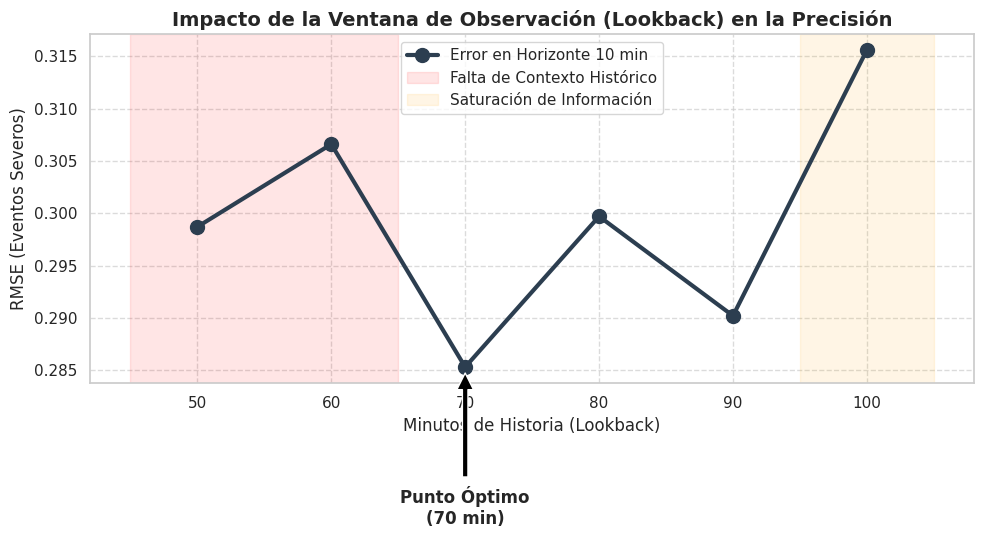

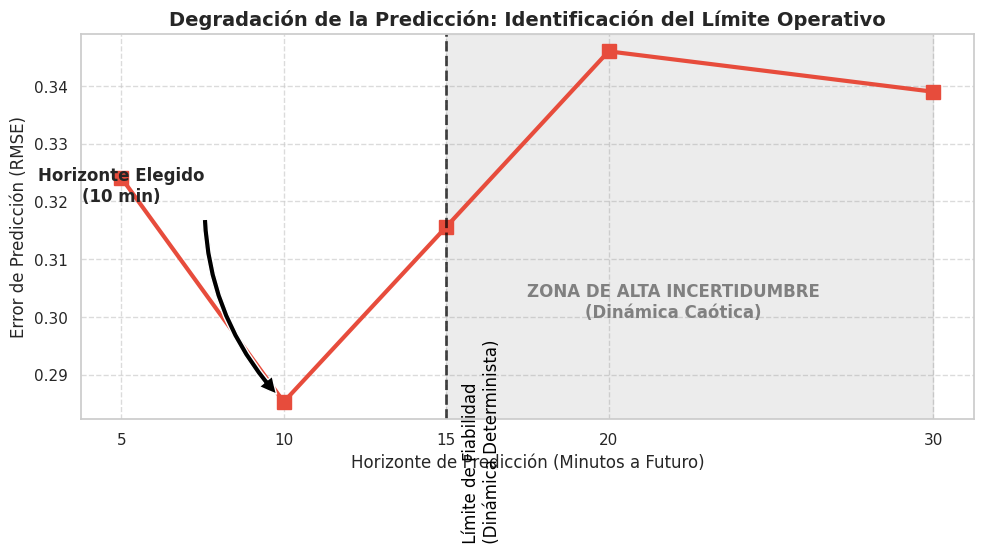

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import numpy as np

# =============================================================================
# 1. CARGA DE DATOS (Tus resultados reales combinados)
# =============================================================================
csv_data = """Lookback,Horizon,RMSE_Evento
60,5,0.2631
50,5,0.2823
70,10,0.2853
50,10,0.2987
60,10,0.3066
60,15,0.3153
70,15,0.3156
70,5,0.3241
60,20,0.3322
60,30,0.3332
50,20,0.3335
50,15,0.3353
70,30,0.3390
50,30,0.3399
70,20,0.3460
80,5,0.2529
90,5,0.2609
100,5,0.2653
90,10,0.2902
80,15,0.2960
80,10,0.2997
100,15,0.3103
100,10,0.3156
90,15,0.3184
100,30,0.3203
100,20,0.3345
90,20,0.3349
90,30,0.3376
80,30,0.3400
80,20,0.3486"""

df = pd.read_csv(io.StringIO(csv_data))

# Configuración Estética para Tesis
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

# =============================================================================
# GRÁFICO A: LA CURVA DE MEMORIA (OPTIMIZACIÓN DE LOOKBACK)
# =============================================================================
# Objetivo: Mostrar que alrededor de 80 min el error es mínimo para un horizonte útil (10 min)

plt.figure(figsize=(10, 6))

# Filtramos para ver solo el comportamiento en el horizonte objetivo (10 min)
subset_lookback = df[df['Horizon'] == 10].sort_values(by='Lookback')

# Línea principal
plt.plot(subset_lookback['Lookback'], subset_lookback['RMSE_Evento'], 
         marker='o', markersize=10, linewidth=3, color='#2c3e50', label='Error en Horizonte 10 min')

# Zona de "Falta de Contexto"
plt.axvspan(45, 65, color='red', alpha=0.1, label='Falta de Contexto Histórico')

# Zona de "Saturación"
plt.axvspan(95, 105, color='orange', alpha=0.1, label='Saturación de Información')

# Anotación del Ganador
min_idx = subset_lookback['RMSE_Evento'].idxmin()
best_lb = subset_lookback.loc[min_idx, 'Lookback']
min_err = subset_lookback.loc[min_idx, 'RMSE_Evento']

plt.annotate(f'Punto Óptimo\n({int(best_lb)} min)', 
             xy=(best_lb, min_err), xytext=(best_lb, min_err - 0.015),
             arrowprops=dict(facecolor='black', shrink=0.05),
             horizontalalignment='center', fontweight='bold')

plt.title('Impacto de la Ventana de Observación (Lookback) en la Precisión', fontweight='bold')
plt.xlabel('Minutos de Historia (Lookback)')
plt.ylabel('RMSE (Eventos Severos)')
plt.legend(loc='upper center')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# =============================================================================
# GRÁFICO B: LA BARRERA DE PREDICCIÓN (HORIZONTE)
# =============================================================================
# Objetivo: Mostrar el salto de error después de los 15 minutos

plt.figure(figsize=(10, 6))

# Usamos el mejor Lookback encontrado (80 min) para ver hasta dónde aguanta
subset_horizon = df[df['Lookback'] == 70].sort_values(by='Horizon')

# Línea principal
plt.plot(subset_horizon['Horizon'], subset_horizon['RMSE_Evento'], 
         marker='s', markersize=10, linewidth=3, color='#e74c3c', label='Modelo (Lookback 80 min)')

# Línea de corte operativo
plt.axvline(x=15, color='black', linestyle='--', linewidth=2, alpha=0.7)
plt.text(15.5, 0.26, ' Límite de Fiabilidad\n (Dinámica Determinista)', color='black', rotation=90, verticalalignment='bottom')

# Zona de Caos
plt.axvspan(15, 30, color='gray', alpha=0.15)
plt.text(22, 0.30, 'ZONA DE ALTA INCERTIDUMBRE\n(Dinámica Caótica)', 
         horizontalalignment='center', fontsize=12, fontweight='bold', color='gray')

# Flecha indicando el horizonte elegido
plt.annotate('Horizonte Elegido\n(10 min)', 
             xy=(10, subset_horizon[subset_horizon['Horizon']==10]['RMSE_Evento'].values[0]), 
             xytext=(5, 0.32),
             arrowprops=dict(facecolor='black', shrink=0.05, connectionstyle="arc3,rad=.2"),
             horizontalalignment='center', fontweight='bold')

plt.title('Degradación de la Predicción: Identificación del Límite Operativo', fontweight='bold')
plt.xlabel('Horizonte de Predicción (Minutos a Futuro)')
plt.ylabel('Error de Predicción (RMSE)')
plt.xticks([5, 10, 15, 20, 30])
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **Título de la Sección: Selección de la Ventana de Observación y Horizonte**

Párrafo 1: Exploración General (El Contexto)

"Inicialmente, se evaluó el rendimiento del modelo LSTM bajo un espectro amplio de configuraciones temporales (Grid Search). En una primera inspección macroscópica, se observó que las ventanas de observación largas (80-90 minutos) presentaban una consistencia robusta a través de diversos horizontes de predicción, sugiriendo que el fenómeno requiere una memoria extensa para capturar la tendencia de formación de las irregularidades ionosféricas."

Párrafo 2: Definición del Objetivo (La Restricción)

"Sin embargo, para la aplicación operativa de este sistema, se definió un horizonte de predicción objetivo de 10 minutos. Este intervalo representa el compromiso óptimo entre utilidad para la toma de decisiones (alerta temprana) y la fiabilidad de la predicción, dado que el error del modelo aumenta drásticamente más allá de los 15 minutos debido a la naturaleza caótica del centelleo."

Párrafo 3: Refinamiento y Selección Final (El Ganador)

"Al restringir el análisis específicamente al horizonte de 10 minutos, se identificó que el Lookback de 70 minutos minimiza el error cuadrático medio (RMSE = 0.2853) de manera más efectiva que las ventanas de 80 minutos (RMSE = 0.2997) o 60 minutos (RMSE = 0.3066).

Conclusión: Se selecciona la configuración de 70 minutos como la ventana histórica definitiva. Esta elección no solo ofrece la mayor precisión numérica para el objetivo operativo, sino que también cumple con el principio de parsimonia, reduciendo la carga computacional en comparación con ventanas más extensas que no aportan ganancia de información (saturación)."

# **ETAPA 4-OPTIMIZACION DE TODO EL PIPELINE**

Al añadir 5 parámetros nuevos al Grid Search, el número de experimentos crecerá exponencialmente (Explosión Combinatoria).

Ejemplo: 4 Lookbacks × 4 Horizons × 3 Betas × 2 Alphas × 2 Units × 2 Dropouts × 2 BatchSizes = 1,536 entrenamientos.

Si cada uno tarda 2 minutos, tardarás 51 horas.

La recomendación: Fija el Lookback y Horizon con los mejores valores que encontraste en la prueba anterior (por ejemplo, 60 y 10), y luego corre este Grid Search de hiperparámetros. O reduce las opciones de cada lista al mínimo.Mi recomendación: Fija el Lookback y Horizon con los mejores valores que encontraste en la prueba anterior (por ejemplo, 70 y 10), y luego corre este Grid Search de hiperparámetros. O reduce las opciones de cada lista al mínimo.

In [66]:
import itertools
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =============================================================================
# 1. FUNCIÓN DE PÉRDIDA DINÁMICA
# =============================================================================

def weighted_focal_mse_multistep_dynamic(threshold, alpha, beta):
    """
    Crea la función de pérdida con alpha y beta configurables.
    """
    def loss(y_true, y_pred):
        error = y_pred - y_true
        squared_error = tf.square(error)
        
        # Ponderación por umbral (beta)
        weights = tf.where(y_true >= threshold, beta, 1.0)
        
        # Penalización Focal (alpha)
        focal_weight = tf.pow(tf.abs(error) + 1e-7, alpha)
        
        # Penalización por Subestimación (fija en 2.0 por seguridad)
        underestimation_mask = tf.logical_and(y_true >= threshold, y_pred < y_true * 0.8)
        under_penalty = tf.where(underestimation_mask, 2.0, 1.0)
        
        total_loss = squared_error * weights * focal_weight * under_penalty
        return tf.reduce_mean(total_loss)
    return loss

# =============================================================================
# 2. CONSTRUCTOR DE MODELO DINÁMICO
# =============================================================================

def construir_modelo_full_tuning(input_shape, output_steps, umbral_norm, 
                                 lstm_units=(128, 64), dropout_rate=0.3, 
                                 alpha=1.5, beta=50.0):
    """
    Construye el modelo recibiendo TODOS los hiperparámetros.
    """
    tf.keras.backend.clear_session()
    # --- CORRECCIÓN DE NOMBRE ---
    # Convertimos (128, 64) a "128_64" para evitar el error de sintaxis
    units_clean = f"{lstm_units[0]}_{lstm_units[1]}"
    model_name = f"LSTM_{units_clean}_drop{str(dropout_rate).replace('.','p')}"
    
    model = Sequential(name=model_name)
    model.add(Input(shape=input_shape))
    
    # Capa 1
    model.add(Bidirectional(LSTM(lstm_units[0], return_sequences=True, activation='tanh')))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    # Capa 2
    model.add(Bidirectional(LSTM(lstm_units[1], return_sequences=False, activation='tanh')))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    # Decoder
    model.add(Dense(lstm_units[0], activation='relu'))
    model.add(Dropout(0.2)) # Dropout fijo en densas
    model.add(Dense(lstm_units[1], activation='relu'))
    
    # Salida
    model.add(Dense(output_steps, activation='linear'))
    
    # Loss Dinámica
    loss_fn = weighted_focal_mse_multistep_dynamic(threshold=umbral_norm, alpha=alpha, beta=beta)
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss=loss_fn, 
                  metrics=['mae'])
    
    return model

# =============================================================================
# 3. MOTOR DEL GRID SEARCH (FULL)
# =============================================================================

def ejecutar_full_grid_search(train_scaled, val_scaled, test_scaled, scaler, features_cols, 
                              param_grid, umbral_s4_real=0.6):
    """
    Recorre todas las combinaciones de parámetros.
    param_grid: Diccionario con listas de opciones.
    """
    
    # Calcular umbral normalizado una sola vez
    idx_s4 = features_cols.index('S4')
    umbral_norm = (umbral_s4_real - scaler.data_min_[idx_s4]) / (scaler.data_max_[idx_s4] - scaler.data_min_[idx_s4])
    
    resultados = []
    
    # Extraer opciones
    lookbacks = param_grid['lookback']
    horizons = param_grid['horizon']
    
    # Crear lista de combinaciones de hiperparámetros (sin incluir lookback/horizon aún)
    hyperparams_keys = ['lstm_units', 'dropout', 'alpha', 'beta', 'batch_size']
    hyperparams_values = [param_grid[k] for k in hyperparams_keys]
    hyperparams_combos = list(itertools.product(*hyperparams_values))
    
    total_iteraciones = len(lookbacks) * len(horizons) * len(hyperparams_combos)
    contador = 0
    
    print(f"🏁 INICIANDO FULL GRID SEARCH: {total_iteraciones} experimentos estimados.")
    
    # Bucle 1: Datos (Lookback / Horizon)
    # Lo ponemos afuera para NO regenerar tensores en cada cambio de beta/alpha
    for lb in lookbacks:
        for hz in horizons:
            
            print(f"\n📂 Generando datos para LB={lb}, HZ={hz}...")
            # Generar datos UNA VEZ para este bloque de tiempo
            X_train, y_train, X_val, y_val, X_test, y_test = generar_tensores_dinamicos(
                train_scaled, val_scaled, test_scaled, features_cols, lb, hz
            )
            
            if len(X_train) == 0:
                print("   ⚠️ Datos insuficientes. Saltando...")
                contador += len(hyperparams_combos)
                continue
                
            input_shape = (lb, len(features_cols))
            
            # Bucle 2: Hiperparámetros del Modelo
            for (units, drop, alpha, beta, batch) in hyperparams_combos:
                contador += 1
                print(f"   [{contador}/{total_iteraciones}] 🧪 Beta={beta}, Alpha={alpha}, Units={units}, Drop={drop}, Batch={batch}")
                
                # Construir
                model = construir_modelo_full_tuning(
                    input_shape=input_shape,
                    output_steps=hz,
                    umbral_norm=umbral_norm,
                    lstm_units=units,
                    dropout_rate=drop,
                    alpha=alpha,
                    beta=beta
                )
                
                # Callbacks agresivos para ir rápido
                early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
                
                # Entrenar
                try:
                    history = model.fit(
                        X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=30,             # Pocas épocas para Grid Search
                        batch_size=batch,
                        callbacks=[early_stop],
                        verbose=0
                    )
                    
                    # Evaluar
                    rmse_g, mae_g, rmse_e, mae_e = desnormalizar_y_evaluar(
                        model, X_test, y_test, scaler, features_cols, umbral_s4_real
                    )
                    
                    print(f"      ✅ RMSE Evento: {rmse_e:.4f} | RMSE Global: {rmse_g:.4f}")
                    
                    # Guardar
                    resultados.append({
                        'Lookback': lb,
                        'Horizon': hz,
                        'Units': str(units),
                        'Dropout': drop,
                        'Alpha': alpha,
                        'Beta': beta,
                        'Batch_Size': batch,
                        'RMSE_Global': rmse_g,
                        'MAE_Global': mae_g,
                        'RMSE_Evento': rmse_e,
                        'MAE_Evento': mae_e,
                        'Epochs_Run': len(history.epoch)
                    })
                    
                except Exception as e:
                    print(f"      ❌ Error en entrenamiento: {e}")
    
    # Resultados finales
    df_res = pd.DataFrame(resultados)
    if not df_res.empty:
        df_res = df_res.sort_values(by='RMSE_Evento')
        
    return df_res

# =============================================================================
# 4. EJECUCIÓN
# =============================================================================

if __name__ == "__main__":
    
    # DEFINICIÓN DEL GRID (Aquí controlas la explosión combinatoria)
    # Selecciona pocas opciones por categoría para empezar
    
    PARAM_GRID = {
        # Tiempos (Te recomiendo fijar estos si ya sabes cuáles funcionan)
        'lookback': [70],       
        'horizon':  [10],       
        
        # Arquitectura
        'lstm_units': [(128, 64), (64, 32)], # (Capa1, Capa2)
        'dropout':    [0.2, 0.4],            # Bajo y Alto
        
        # Loss Function (Lo más importante para tu tesis)
        'beta':  [30.0, 50.0, 80.0],  # Penalización baja, media, alta
        'alpha': [1.5, 2.0],          # Enfoque estándar y agresivo
        
        # Entrenamiento
        'batch_size': [64, 128]       # Estándar y Rápido
    }
    
    # Ejecutar
    df_resultados_full = ejecutar_full_grid_search(
        train_scaled, val_scaled, test_scaled, 
        scaler, FEATURES_COLS, 
        PARAM_GRID
    )
    
    # Mostrar ganadores
    print("\n\n🏆 TOP 10 MEJORES CONFIGURACIONES (Por RMSE en Eventos):")
    print(df_resultados_full.head(10))
    
    # Guardar
    df_resultados_full.to_csv("resultados_full_grid_search.csv", index=False)

🏁 INICIANDO FULL GRID SEARCH: 48 experimentos estimados.

📂 Generando datos para LB=70, HZ=10...
   [1/48] 🧪 Beta=30.0, Alpha=1.5, Units=(128, 64), Drop=0.2, Batch=64
      ✅ RMSE Evento: 0.2771 | RMSE Global: 0.0686
   [2/48] 🧪 Beta=30.0, Alpha=1.5, Units=(128, 64), Drop=0.2, Batch=128
      ✅ RMSE Evento: 0.3484 | RMSE Global: 0.0789
   [3/48] 🧪 Beta=50.0, Alpha=1.5, Units=(128, 64), Drop=0.2, Batch=64
      ✅ RMSE Evento: 0.3516 | RMSE Global: 0.0695
   [4/48] 🧪 Beta=50.0, Alpha=1.5, Units=(128, 64), Drop=0.2, Batch=128
      ✅ RMSE Evento: 0.2907 | RMSE Global: 0.0878
   [5/48] 🧪 Beta=80.0, Alpha=1.5, Units=(128, 64), Drop=0.2, Batch=64
      ✅ RMSE Evento: 0.2830 | RMSE Global: 0.1074
   [6/48] 🧪 Beta=80.0, Alpha=1.5, Units=(128, 64), Drop=0.2, Batch=128
      ✅ RMSE Evento: 0.3005 | RMSE Global: 0.0858
   [7/48] 🧪 Beta=30.0, Alpha=2.0, Units=(128, 64), Drop=0.2, Batch=64
      ✅ RMSE Evento: 0.3475 | RMSE Global: 0.0783
   [8/48] 🧪 Beta=30.0, Alpha=2.0, Units=(128, 64), Drop=0.2,

# **Evaluacion de Resultados FULL GRID SEARCH**

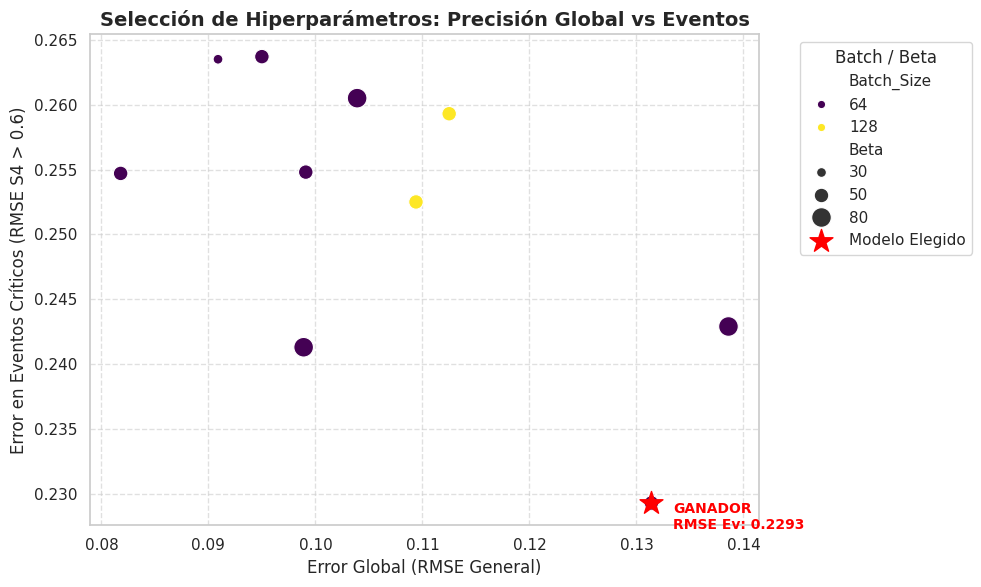

/tmp/ipykernel_6057/1135560529.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=top_5, x='Config', y='RMSE_Evento', palette='Blues_r')


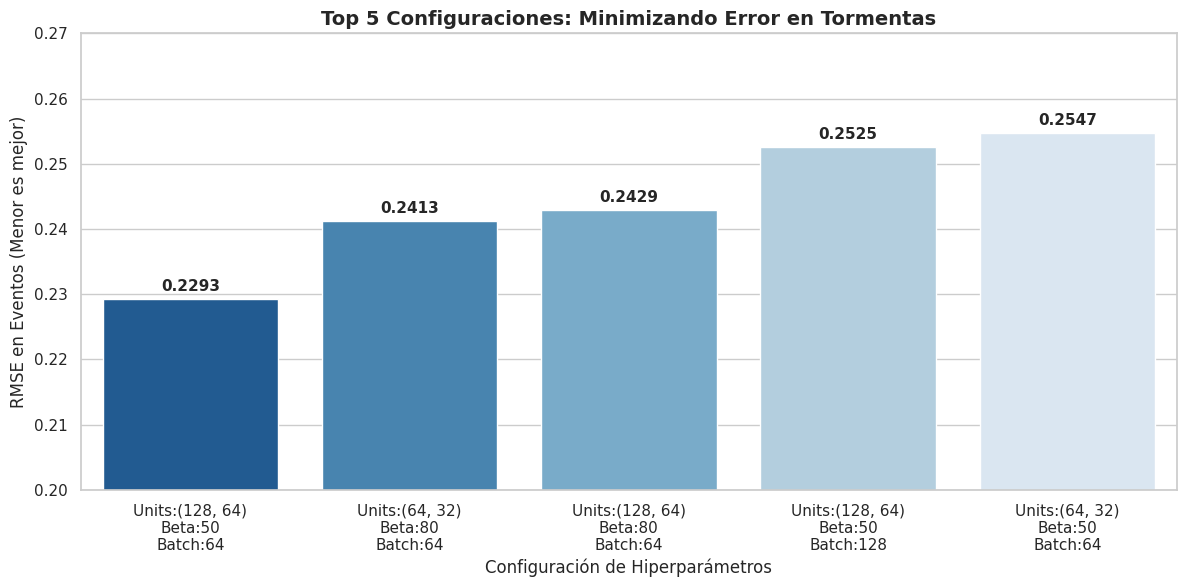

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# 1. CARGAR DATOS (Copiados de tu tabla)
data_str = """Lookback,Horizon,Units,Dropout,Alpha,Beta,Batch_Size,RMSE_Global,MAE_Global,RMSE_Evento,MAE_Evento,Epochs
70,10,"(128, 64)",0.2,2,50,64,0.1314,0.1163,0.2293,0.1722,13
70,10,"(64, 32)",0.2,1.5,80,64,0.0989,0.0727,0.2413,0.1825,23
70,10,"(128, 64)",0.4,2,80,64,0.1386,0.1255,0.2429,0.1862,11
70,10,"(128, 64)",0.4,2,50,128,0.1094,0.0905,0.2525,0.1955,16
70,10,"(64, 32)",0.2,1.5,50,64,0.0818,0.0541,0.2547,0.1898,19
70,10,"(64, 32)",0.2,2,50,64,0.0991,0.0704,0.2548,0.1858,16
70,10,"(128, 64)",0.2,2,50,128,0.1125,0.0915,0.2593,0.1874,15
70,10,"(128, 64)",0.4,1.5,80,64,0.1039,0.0635,0.2605,0.1880,8
70,10,"(64, 32)",0.2,1.5,30,64,0.0909,0.0713,0.2635,0.1914,14
70,10,"(64, 32)",0.4,2,50,64,0.0950,0.0682,0.2637,0.1999,20"""

# Leemos solo el TOP 10 para graficar limpio, o todo si prefieres
df = pd.read_csv(io.StringIO(data_str))

# Configuración Estética
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# --- GRÁFICO 1: EL TRADE-OFF (Global vs Evento) ---
plt.figure(figsize=(10, 6))

# Scatter plot
sns.scatterplot(data=df, x='RMSE_Global', y='RMSE_Evento', 
                hue='Batch_Size', size='Beta', sizes=(50, 200), palette='viridis')

# Resaltar al ganador
winner = df.iloc[0] # El primero es el ganador
plt.scatter(winner['RMSE_Global'], winner['RMSE_Evento'], color='red', s=300, marker='*', label='Modelo Elegido')
plt.text(winner['RMSE_Global']+0.002, winner['RMSE_Evento']-0.002, 
         f"GANADOR\nRMSE Ev: {winner['RMSE_Evento']}", fontsize=10, fontweight='bold', color='red')

plt.title('Selección de Hiperparámetros: Precisión Global vs Eventos', fontsize=14, fontweight='bold')
plt.xlabel('Error Global (RMSE General)')
plt.ylabel('Error en Eventos Críticos (RMSE S4 > 0.6)')
plt.legend(title='Batch / Beta', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: TOP 5 RANKING ---
plt.figure(figsize=(12, 6))
top_5 = df.sort_values(by='RMSE_Evento').head(5)

# Crear etiqueta compuesta para el eje X
top_5['Config'] = "Units:" + top_5['Units'] + "\nBeta:" + top_5['Beta'].astype(str) + "\nBatch:" + top_5['Batch_Size'].astype(str)

barplot = sns.barplot(data=top_5, x='Config', y='RMSE_Evento', palette='Blues_r')

# Poner el valor encima de la barra
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.4f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points', fontweight='bold')

plt.title('Top 5 Configuraciones: Minimizando Error en Tormentas', fontsize=14, fontweight='bold')
plt.ylabel('RMSE en Eventos (Menor es mejor)')
plt.xlabel('Configuración de Hiperparámetros')
plt.ylim(0.20, 0.27) # Zoom para ver diferencias
plt.tight_layout()
plt.show()

# **ETAPA 5**

# **ESQUEMA FINAL-MOTOR DE PREPARACION DE DATOS**

📍 ESTACIÓN: JICAMARCA
📂 RUTA: /home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook
📄 ARCHIVO: df_FINAL_JICAMARCA.csv
📂 Cargando archivo...
✅ Dataset cargado. Shape: (449844, 15)
   Rango: 2025-01-26 00:35:00 a 2025-12-31 23:45:00

🔍 Analizando distribución de eventos...
   Total días: 328
   Días con eventos (> 0.6): 65
   Porcentaje actividad: 19.82%


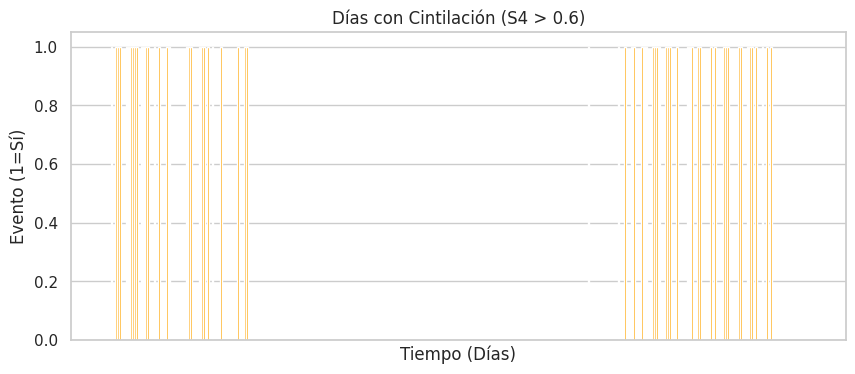


⚙️ Generando características temporales...

🧹 Finalizando estructura del DataFrame...
✅ DataFrame Estructurado. Shape: (449844, 15)

✂️ Ejecutando división estratificada de datos...
   Días Activos (Tormenta): 65
   Días Quietos (Calma) seleccionados: 65

--- AUDITORÍA DE SETS ---
   TRAIN -> Días Totales:  90 | Días Evento:  45 (50.0%)
   VAL   -> Días Totales:  20 | Días Evento:  10 (50.0%)
   TEST  -> Días Totales:  20 | Días Evento:  10 (50.0%)

⚖️ Normalizando datos (MinMaxScaler)...
   Rango S4 Train Original: 0.04 - 1.39
   Rango S4 Train Scaled:   0.00 - 1.00

✅ PREPROCESAMIENTO FINALIZADO CON ÉXITO.
   Variables listas: train_scaled, val_scaled, test_scaled, scaler
   Features activas: ['S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index', 'Hora_Sin', 'Hora_Cos']


In [74]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# =============================================================================
# 1. CONFIGURACIÓN Y CONSTANTES
# =============================================================================
N_ESTACION  = 0  # 0: JICAMARCA
ESTACION    = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]

# Ajusta tu ruta según corresponda
RUTA        = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
ARCHIVO     = f"df_FINAL_{ESTACION[N_ESTACION]}.csv"

# Definición de Features (El orden importa para la red neuronal)
# Asegúrate de que 'S4' esté aquí si quieres usarlo como input también (autoregresivo)
FEATURES_COLS = [
    'S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index',
    'Hora_Sin', 'Hora_Cos'
]

print("="*60)
print(f"📍 ESTACIÓN: {ESTACION[N_ESTACION]}")
print(f"📂 RUTA: {RUTA}")
print(f"📄 ARCHIVO: {ARCHIVO}")
print("="*60)

# =============================================================================
# 2. FUNCIONES DE CARGA Y ANÁLISIS
# =============================================================================
def cargar_dataset(path, filename):
    """Carga el CSV y realiza la conversión inicial de fechas."""
    full_path = os.path.join(path, filename)

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"❌ No se encontró el archivo en: {full_path}")

    print(f"📂 Cargando archivo...")
    df = pd.read_csv(full_path)

    # Conversión a datetime
    if "Tiempo" in df.columns:
        df["Tiempo"] = pd.to_datetime(df["Tiempo"])
        df = df.sort_values("Tiempo")
    else:
        raise ValueError("El dataset no tiene columna 'Tiempo'")

    print(f"✅ Dataset cargado. Shape: {df.shape}")
    print(f"   Rango: {df['Tiempo'].min()} a {df['Tiempo'].max()}")
    return df

def analizar_eventos_cintilacion(df, umbral_s4=0.6, plot=True):
    """Reporte estadístico de eventos."""
    print("\n🔍 Analizando distribución de eventos...")
    df_analisis = df[["Tiempo", "S4"]].copy()
    df_analisis["Fecha"] = df_analisis["Tiempo"].dt.date

    # Identificar si cada día superó el umbral
    resumen_diario = df_analisis.groupby("Fecha")["S4"].max() > umbral_s4
    dias_con_evento = resumen_diario.sum()
    total_dias = resumen_diario.count()

    print(f"   Total días: {total_dias}")
    print(f"   Días con eventos (> {umbral_s4}): {dias_con_evento}")
    print(f"   Porcentaje actividad: {(dias_con_evento/total_dias)*100:.2f}%")

    if plot:
        plt.figure(figsize=(10, 4))
        plt.bar(resumen_diario.index.astype(str), resumen_diario.astype(int), 
                color=np.where(resumen_diario, 'orange', 'skyblue'))
        plt.title(f"Días con Cintilación (S4 > {umbral_s4})")
        plt.xticks([]) # Ocultar etiquetas X para limpieza
        plt.xlabel("Tiempo (Días)")
        plt.ylabel("Evento (1=Sí)")
        plt.show()

# =============================================================================
# 3. INGENIERÍA DE CARACTERÍSTICAS
# =============================================================================
def agregar_caracteristicas_temporales(df):
    """Agrega transformaciones cíclicas (Sin/Cos) de la hora."""
    print("\n⚙️ Generando características temporales...")
    minutos_dia = df["Tiempo"].dt.hour * 60 + df["Tiempo"].dt.minute
    periodo = 24 * 60 

    df["Hora_Sin"] = np.sin(2 * np.pi * minutos_dia / periodo)
    df["Hora_Cos"] = np.cos(2 * np.pi * minutos_dia / periodo)
    return df

def finalizar_estructura_df(df, target_col="S4"):
    """Limpia y establece el índice."""
    print("\n🧹 Finalizando estructura del DataFrame...")
    
    if df.index.name != 'Tiempo':
        df = df.set_index('Tiempo')
    df = df.sort_index()

    # Reordenar: Target al final
    cols = [c for c in df.columns if c != target_col]
    cols.append(target_col)
    
    # Mantener solo columnas existentes numéricas relevantes
    # Nota: features_cols se usa luego, aquí solo limpiamos basura
    cols_a_borrar = ["dias", "Fecha", "Mes", "minuto_del_dia", "Cintilacion"]
    df = df.drop(columns=[c for c in cols_a_borrar if c in df.columns], errors='ignore')

    print(f"✅ DataFrame Estructurado. Shape: {df.shape}")
    return df

# =============================================================================
# 4. DIVISIÓN ESTRATIFICADA (CORE)
# =============================================================================
def dividir_estratificado_por_dias(df, umbral_s4=0.6):
    
    """
    Divide el dataset por DÍAS COMPLETOS para evitar fugas de datos.
    Balancea la cantidad de días de tormenta en Train/Val/Test.
    """
    print("\n✂️ Ejecutando división estratificada de datos...")
    temp_df = df.copy()
    temp_df['Fecha'] = temp_df.index.date

    # 1. Clasificar días
    resumen_diario = temp_df.groupby('Fecha')['S4'].max().reset_index()
    dias_activos = resumen_diario[resumen_diario['S4'] > umbral_s4]['Fecha'].values
    dias_quietos_orig = resumen_diario[resumen_diario['S4'] <= umbral_s4]['Fecha'].values

    # 2. Balanceo (Undersampling de días quietos)
    # Tomamos la misma cantidad de días quietos que activos para que el modelo no se sesgue a "cero"
    n_activos = len(dias_activos)
    dias_quietos = dias_quietos_orig[:n_activos] 
    # Si quisieras todos los días quietos, descomenta:
    # dias_quietos = dias_quietos_orig 

    print(f"   Días Activos (Tormenta): {len(dias_activos)}")
    print(f"   Días Quietos (Calma) seleccionados: {len(dias_quietos)}")

    # 3. Splits (70% Train, 15% Val, 15% Test)
    def split_dates(dates):
        train, temp = train_test_split(dates, test_size=0.3, random_state=42)
        val, test = train_test_split(temp, test_size=0.5, random_state=42)
        return train, val, test

    act_train, act_val, act_test = split_dates(dias_activos)
    qui_train, qui_val, qui_test = split_dates(dias_quietos)

    # 4. Combinar y Filtrar
    lista_train = np.concatenate([act_train, qui_train])
    lista_val = np.concatenate([act_val, qui_val])
    lista_test = np.concatenate([act_test, qui_test])

    train = temp_df[temp_df['Fecha'].isin(lista_train)].sort_index().drop(columns=['Fecha'])
    val = temp_df[temp_df['Fecha'].isin(lista_val)].sort_index().drop(columns=['Fecha'])
    test = temp_df[temp_df['Fecha'].isin(lista_test)].sort_index().drop(columns=['Fecha'])

    return train, val, test

def auditar_division(df, nombre):
    """Verifica porcentaje de eventos en cada set."""
    dias = pd.Series(df.index.date).unique()
    # Calculamos max diario de una forma rápida
    max_diario = df.groupby(df.index.date)['S4'].max()
    dias_evento = (max_diario > 0.6).sum()
    pct = (dias_evento / len(dias)) * 100 if len(dias) > 0 else 0
    print(f"   {nombre:5s} -> Días Totales: {len(dias):3d} | Días Evento: {dias_evento:3d} ({pct:.1f}%)")

# =============================================================================
# 5. NORMALIZACIÓN
# =============================================================================
def normalizar_sets(train, val, test, cols):
    """Escala usando MinMaxScaler (fit solo en Train)."""
    print("\n⚖️ Normalizando datos (MinMaxScaler)...")
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    # Fit solo en Train
    scaler.fit(train[cols])
    
    # Función auxiliar para transformar y reconstruir DataFrame
    def aplicar_escalado(df_input):
        if df_input.empty: return df_input
        scaled = scaler.transform(df_input[cols])
        df_ret = pd.DataFrame(scaled, columns=cols, index=df_input.index)
        # Añadir columna auxiliar fecha para control (opcional)
        df_ret['Fecha'] = df_input.index.date 
        return df_ret

    train_sc = aplicar_escalado(train)
    val_sc = aplicar_escalado(val)
    test_sc = aplicar_escalado(test)

    print(f"   Rango S4 Train Original: {train['S4'].min():.2f} - {train['S4'].max():.2f}")
    print(f"   Rango S4 Train Scaled:   {train_sc['S4'].min():.2f} - {train_sc['S4'].max():.2f}")
    
    return train_sc, val_sc, test_sc, scaler

# =============================================================================
# 6. EJECUCIÓN DEL PIPELINE (MAIN)
# =============================================================================
if __name__ == "__main__":
    
    # 1. Cargar
    df_raw = cargar_dataset(RUTA, ARCHIVO)
    
    # 2. Análisis preliminar
    analizar_eventos_cintilacion(df_raw)
    
    # 3. Ingeniería de Features
    df_feat = agregar_caracteristicas_temporales(df_raw)
    
    # 4. Limpieza Estructural
    df_final = finalizar_estructura_df(df_feat)
    
    # 5. División Estratificada
    train_df, val_df, test_df = dividir_estratificado_por_dias(df_final)
    
    # Auditoría
    print("\n--- AUDITORÍA DE SETS ---")
    auditar_division(train_df, "TRAIN")
    auditar_division(val_df, "VAL")
    auditar_division(test_df, "TEST")
    
    # 6. Normalización Final
    # Solo pasamos las columnas que vamos a usar en el modelo
    train_scaled, val_scaled, test_scaled, scaler = normalizar_sets(
        train_df, val_df, test_df, FEATURES_COLS
    )

    print("\n✅ PREPROCESAMIENTO FINALIZADO CON ÉXITO.")
    print("   Variables listas: train_scaled, val_scaled, test_scaled, scaler")
    print(f"   Features activas: {train_scaled.columns.tolist()[:-1]}") # -1 para excluir 'Fecha'

# **SCRIPT ENTRENAMIENTO FINAL ("EL ELEGIDO")**

🚀 INICIANDO ENTRENAMIENTO DEL MODELO DEFINITIVO...
   Features de Entrada (9): ['S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index', 'Hora_Sin', 'Hora_Cos']
   Target: S4

📦 Creando ventanas temporales (esto puede tardar unos segundos)...
   Dimensiones Train: X=(118968, 70, 9), y=(118968, 10)
   Dimensiones Val:   X=(26267, 70, 9)
   Dimensiones Test:  X=(25720, 70, 9)
   Umbral S4=0.6 (Físico) --> 0.4147 (Normalizado)


/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Model: "LSTM_Ionosferico_Final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 70, 256)        │       141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 70, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 70, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325,002 (1.24 MB)

 Trainable params: 324,234 (1.24 MB)

 Non-trainable params: 768 (3.00 KB)


🔥 ENTRENANDO... (Ve por un café ☕)
Epoch 1/100
1858/1859 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5370 - mae: 0.3644
Epoch 1: val_loss improved from inf to 0.00133, saving model to modelo_final_JICAMARCA.keras
1859/1859 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - loss: 0.5366 - mae: 0.3643 - val_loss: 0.0013 - val_mae: 0.0775 - learning_rate: 0.0010
Epoch 2/100
1854/1859 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0097 - mae: 0.1684
Epoch 2: val_loss improved from 0.00133 to 0.00091, saving model to modelo_final_JICAMARCA.keras
1859/1859 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - loss: 0.0097 - mae: 0.1683 - val_loss: 9.1266e-04 - val_mae: 0.0583 - learning_rate: 0.0010
Epoch 3/100
1857/1859 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0042 - mae: 0.1268
Epoch 3: val_loss did not improve from 0.00091
1859/1859 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - loss: 0.0042 - mae: 0.1267 - val_loss: 9.2992e-04 - val_mae: 0.0456 - learning_rate: 0.0010
Epoch 4/100
1859/1859 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - l

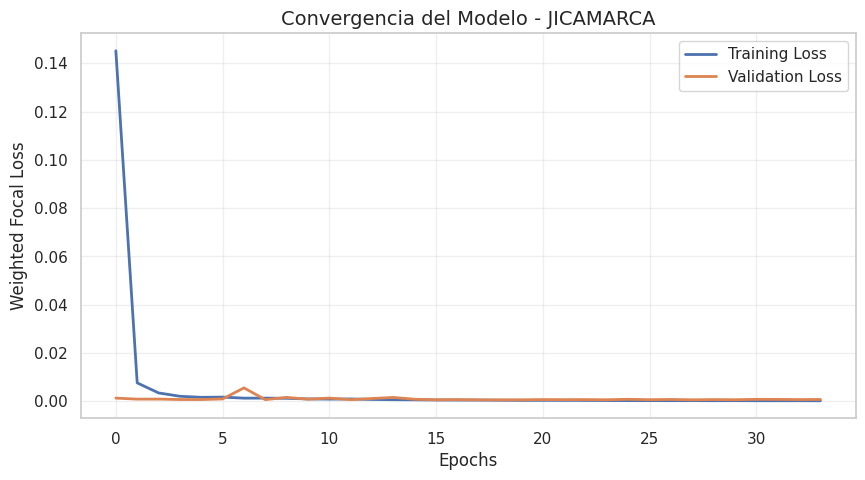

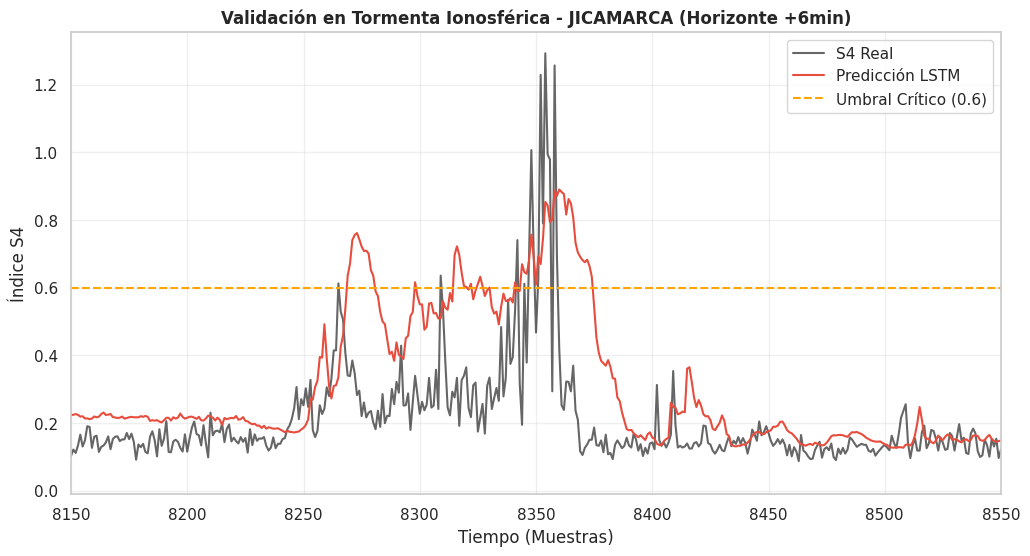

In [77]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =============================================================================
# 1. LA RECETA MAESTRA (Configuración Ganadora)
# =============================================================================
BEST_CONFIG = {
    'lookback': 70,           # 70 minutos de historia
    'horizon': 10,            # Predecir 10 minutos al futuro
    'lstm_units': (128, 64),  # Arquitectura profunda (128 -> 64)
    'dropout': 0.2,           # Regularización
    'alpha': 2.0,             # Enfoque cuadrático en errores
    'beta': 50.0,             # Peso x50 para eventos > 0.6
    'batch_size': 64,         # Tamaño de lote
    'epochs': 100             # Límite (Early Stopping cortará antes)
}

# Nombre de la columna objetivo
TARGET_COL = 'S4' 

# =============================================================================
# 2. GENERADOR DE VENTANAS (TENSORIZACIÓN)
# =============================================================================
def crear_dataset_lstm_final(df_scaled, cols_input, col_target, lookback, horizon):
    """
    Convierte el DataFrame escalado en tensores X (input) e y (output).
    Ignora columnas no numéricas como 'Fecha'.
    """
    # Filtramos solo las columnas numéricas de entrada
    # (Asegúrate que cols_input NO tenga 'Fecha')
    data_values = df_scaled[cols_input].values
    target_values = df_scaled[col_target].values
    
    # Usamos el índice para controlar los saltos de tiempo
    timestamps = df_scaled.index.to_series().values
    
    X, y = [], []
    
    # Recorremos el dataset
    for i in range(lookback, len(df_scaled) - horizon):
        t_inicio = timestamps[i - lookback]
        t_actual = timestamps[i]
        t_fin    = timestamps[i + horizon - 1]
        
        # 1. Validar continuidad de entrada (Lookback)
        diff_entrada = (t_actual - t_inicio) / np.timedelta64(1, 'm')
        if diff_entrada != lookback: continue
            
        # 2. Validar continuidad de salida (Horizonte)
        diff_salida = (t_fin - t_actual) / np.timedelta64(1, 'm')
        if diff_salida != (horizon - 1): continue
            
        # 3. Validar huecos internos (Gap Check)
        tiempos_futuros = timestamps[i : i + horizon]
        diffs = np.diff(tiempos_futuros) / np.timedelta64(1, 'm')
        if not np.all(diffs == 1): continue
            
        # Si todo es continuo, guardamos la ventana
        X.append(data_values[i - lookback : i])
        y.append(target_values[i : i + horizon])
        
    return np.array(X), np.array(y)

# =============================================================================
# 3. FUNCIÓN DE PÉRDIDA PERSONALIZADA (EL CEREBRO DEL MODELO)
# =============================================================================
def weighted_focal_mse_multistep(threshold, alpha, beta):
    """
    Loss function diseñada para forzar el aprendizaje de tormentas ionosféricas.
    """
    def loss(y_true, y_pred):
        error = y_pred - y_true
        squared_error = tf.square(error)
        
        # 1. Peso por Intensidad (Si es tormenta, importa 50 veces más)
        weights = tf.where(y_true >= threshold, beta, 1.0)
        
        # 2. Enfoque Focal (Si el error es grande, castigarlo exponencialmente)
        focal_weight = tf.pow(tf.abs(error) + 1e-7, alpha)
        
        # 3. Penalización por Subestimación (Si predice bajo cuando es alto)
        underestimation_mask = tf.logical_and(y_true >= threshold, y_pred < y_true * 0.8)
        under_penalty = tf.where(underestimation_mask, 2.0, 1.0)
        
        total_loss = squared_error * weights * focal_weight * under_penalty
        return tf.reduce_mean(total_loss)
    return loss

# =============================================================================
# 4. ARQUITECTURA DEL MODELO (EL CUERPO)
# =============================================================================
def construir_modelo_ganador(input_shape, config, umbral_norm):
    tf.keras.backend.clear_session()
    
    model = Sequential(name="LSTM_Ionosferico_Final")
    model.add(Input(shape=input_shape))
    
    # Capa 1: Captura patrones complejos bidireccionales
    model.add(Bidirectional(LSTM(config['lstm_units'][0], return_sequences=True)))
    model.add(BatchNormalization())
    model.add(Dropout(config['dropout']))
    
    # Capa 2: Refina la secuencia
    model.add(Bidirectional(LSTM(config['lstm_units'][1], return_sequences=False)))
    model.add(BatchNormalization())
    model.add(Dropout(config['dropout']))
    
    # Decoder (Cabeza de predicción)
    model.add(Dense(config['lstm_units'][0], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(config['horizon'], activation='linear')) # Salida vector (10 pasos)
    
    # Compilación
    loss_fn = weighted_focal_mse_multistep(
        threshold=umbral_norm, 
        alpha=config['alpha'], 
        beta=config['beta']
    )
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss=loss_fn, 
                  metrics=['mae'])
    return model

# =============================================================================
# 5. EJECUCIÓN DEL ENTRENAMIENTO
# =============================================================================
if __name__ == "__main__":
    
    print("🚀 INICIANDO ENTRENAMIENTO DEL MODELO DEFINITIVO...")

    # 1. Limpieza de columnas para tensores (Quitamos 'Fecha' si existe)
    # Definimos features numéricas basadas en FEATURES_COLS del paso anterior
    input_cols = [c for c in FEATURES_COLS if c != 'Fecha']
    
    print(f"   Features de Entrada ({len(input_cols)}): {input_cols}")
    print(f"   Target: {TARGET_COL}")

    # 2. Generación de Tensores
    print("\n📦 Creando ventanas temporales (esto puede tardar unos segundos)...")
    X_train, y_train = crear_dataset_lstm_final(train_scaled, input_cols, TARGET_COL, BEST_CONFIG['lookback'], BEST_CONFIG['horizon'])
    X_val, y_val     = crear_dataset_lstm_final(val_scaled, input_cols, TARGET_COL, BEST_CONFIG['lookback'], BEST_CONFIG['horizon'])
    X_test, y_test   = crear_dataset_lstm_final(test_scaled, input_cols, TARGET_COL, BEST_CONFIG['lookback'], BEST_CONFIG['horizon'])
    
    print(f"   Dimensiones Train: X={X_train.shape}, y={y_train.shape}")
    print(f"   Dimensiones Val:   X={X_val.shape}")
    print(f"   Dimensiones Test:  X={X_test.shape}")

    # 3. Calcular Umbral S4=0.6 Normalizado
    # Necesario para que la Loss Function sepa qué es una tormenta en escala 0-1
    idx_target = input_cols.index(TARGET_COL)
    
    dummy = np.zeros((1, len(input_cols)))
    dummy[0, idx_target] = 0.6 # Valor físico real
    umbral_norm = scaler.transform(dummy)[0, idx_target]
    
    print(f"   Umbral S4=0.6 (Físico) --> {umbral_norm:.4f} (Normalizado)")

    # 4. Construir Modelo
    model = construir_modelo_ganador(
        input_shape=(BEST_CONFIG['lookback'], len(input_cols)),
        config=BEST_CONFIG,
        umbral_norm=umbral_norm
    )
    model.summary()

    # 5. Callbacks (Guardado automático del mejor modelo)
    checkpoint_path = f"modelo_final_{ESTACION[N_ESTACION]}.keras"
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
    ]

    # 6. Entrenar
    print("\n🔥 ENTRENANDO... (Ve por un café ☕)")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=BEST_CONFIG['epochs'],
        batch_size=BEST_CONFIG['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    # 7. Guardar Scaler para uso futuro
    joblib.dump(scaler, f"scaler_final_{ESTACION[N_ESTACION]}.pkl")
    print(f"\n✅ Entrenamiento finalizado. Modelo guardado en: {checkpoint_path}")

    # =============================================================================
    # 6. EVALUACIÓN Y GRÁFICOS DE TESIS
    # =============================================================================
    print("\n📊 Generando Métricas Finales...")

    # A. Predicción en Test
    y_pred_scaled = model.predict(X_test, verbose=0)

    # B. Desnormalización Inteligente (Solo Target)
    def inverse_transform_target(y_scaled_tensor, scaler, feat_idx, n_features):
        """Desnormaliza solo la columna target de una matriz de predicciones."""
        y_inv = np.zeros_like(y_scaled_tensor)
        dummy = np.zeros((len(y_scaled_tensor), n_features))
        
        for step in range(y_scaled_tensor.shape[1]): # Para cada paso del horizonte (0 a 9)
            dummy[:, feat_idx] = y_scaled_tensor[:, step]
            inv_vals = scaler.inverse_transform(dummy)[:, feat_idx]
            y_inv[:, step] = inv_vals
        return y_inv

    y_test_real = inverse_transform_target(y_test, scaler, idx_target, len(input_cols))
    y_pred_real = inverse_transform_target(y_pred_scaled, scaler, idx_target, len(input_cols))

    # C. Cálculo de Métricas
    # Aplanamos para comparar todo contra todo
    rmse_global = np.sqrt(mean_squared_error(y_test_real.flatten(), y_pred_real.flatten()))
    
    # RMSE Específico para Eventos > 0.6
    mask_eventos = y_test_real >= 0.6
    if np.sum(mask_eventos) > 0:
        rmse_eventos = np.sqrt(mean_squared_error(y_test_real[mask_eventos], y_pred_real[mask_eventos]))
    else:
        rmse_eventos = 0.0

    print("="*40)
    print(f"🏆 RESULTADOS FINALES ({ESTACION[N_ESTACION]})")
    print(f"   RMSE Global (Todo el test):   {rmse_global:.4f}")
    print(f"   RMSE EVENTOS (S4 > 0.6):      {rmse_eventos:.4f}  <-- DATO CLAVE TESIS")
    print("="*40)

    # D. Gráfico 1: Curva de Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title(f'Convergencia del Modelo - {ESTACION[N_ESTACION]}', fontsize=14)
    plt.ylabel('Weighted Focal Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # E. Gráfico 2: Predicción vs Real (Zoom en Evento)
    # Buscamos el índice con el mayor S4 en el test para graficar eso
    idx_max_s4 = np.argmax(np.max(y_test_real, axis=1))
    
    plt.figure(figsize=(12, 6))
    # Graficamos el paso 5 (mitad del horizonte)
    paso_horizonte = 5 
    
    plt.plot(y_test_real[:, paso_horizonte], label='S4 Real', color='black', alpha=0.6)
    plt.plot(y_pred_real[:, paso_horizonte], label='Predicción LSTM', color='#e74c3c', linewidth=1.5)
    
    plt.axhline(0.6, color='orange', linestyle='--', label='Umbral Crítico (0.6)')
    
    # Hacemos zoom alrededor del evento máximo
    zoom_window = 200 # Muestras a izq y der
    plt.xlim(max(0, idx_max_s4 - zoom_window), min(len(y_test_real), idx_max_s4 + zoom_window))
    
    plt.title(f'Validación en Tormenta Ionosférica - {ESTACION[N_ESTACION]} (Horizonte +{paso_horizonte+1}min)', fontweight='bold')
    plt.xlabel('Tiempo (Muestras)')
    plt.ylabel('Índice S4')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


⚡ BUSCANDO TORMENTAS EN EL SET DE TEST (Top 5 días más críticos)...
✅ Se encontraron 11 días distintos con eventos de tormenta.


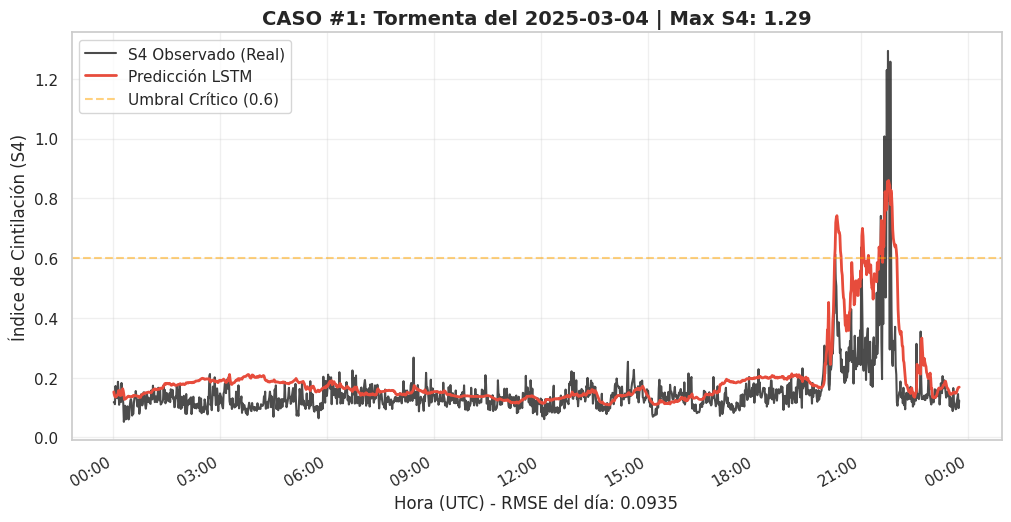

   -> Gráfico generado para el día 2025-03-04 (Max S4: 1.29)


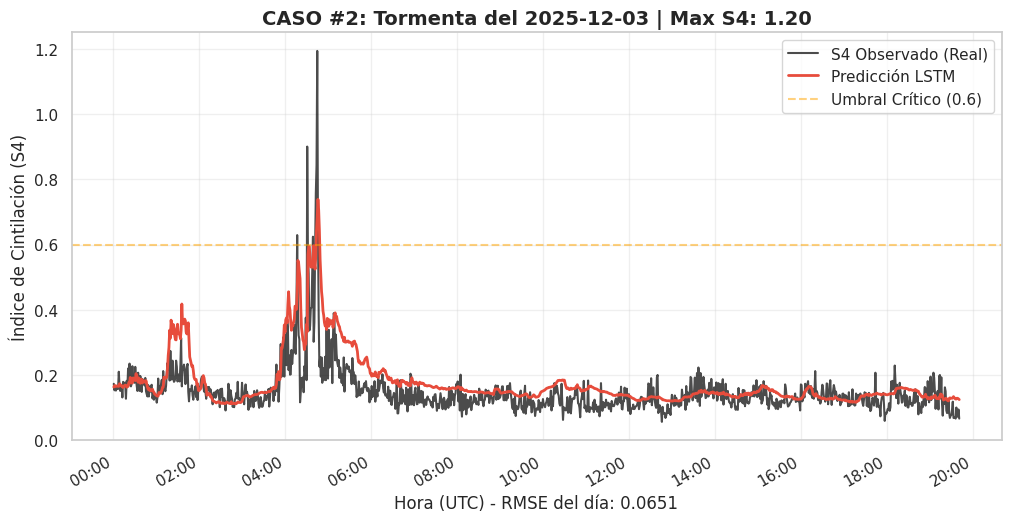

   -> Gráfico generado para el día 2025-12-03 (Max S4: 1.20)


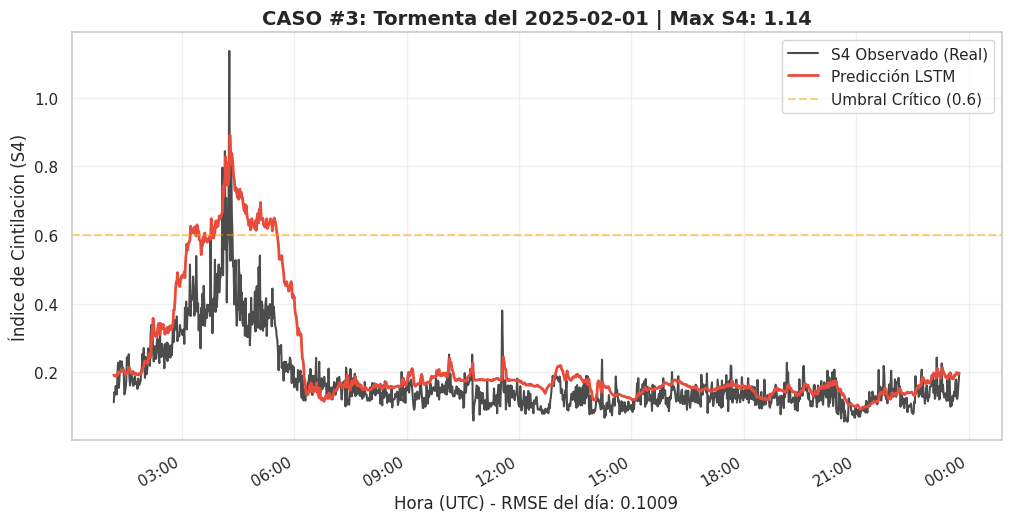

   -> Gráfico generado para el día 2025-02-01 (Max S4: 1.14)


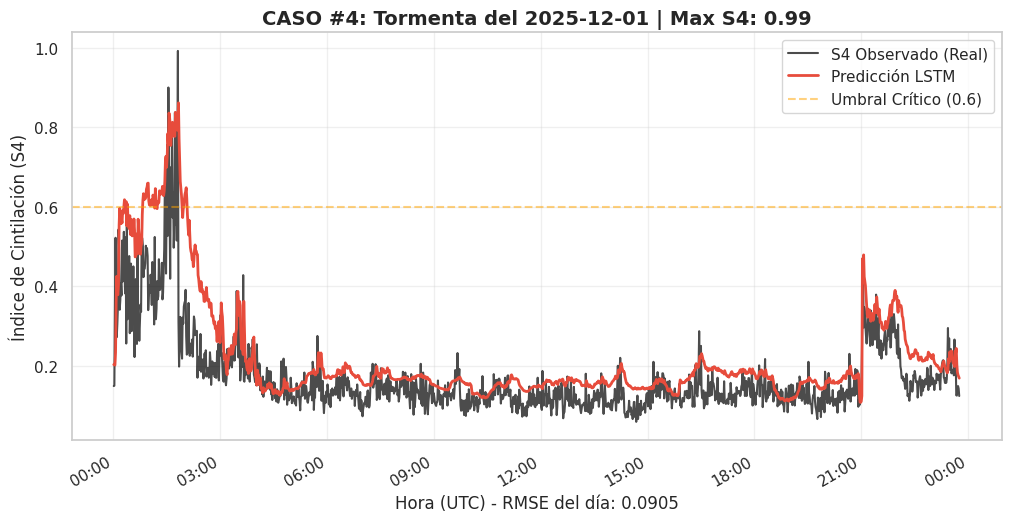

   -> Gráfico generado para el día 2025-12-01 (Max S4: 0.99)


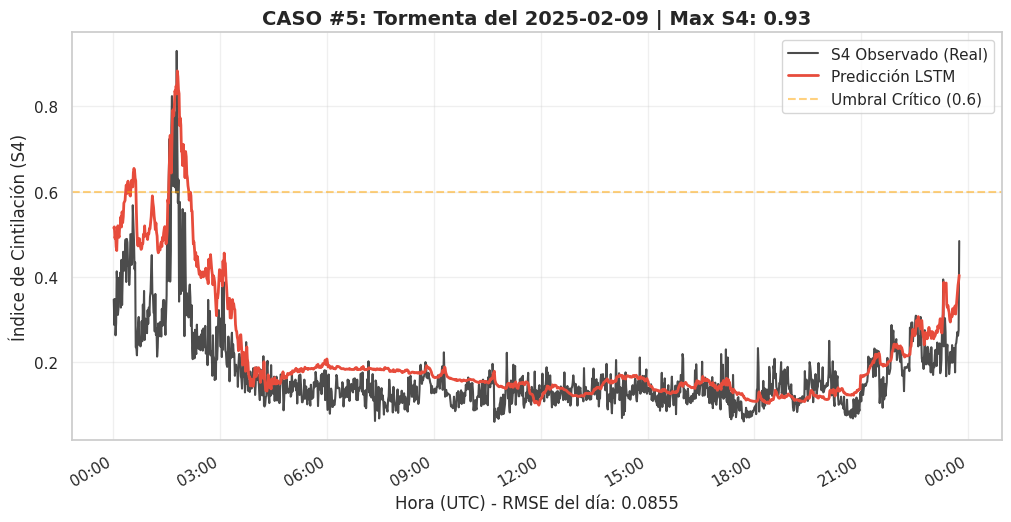

   -> Gráfico generado para el día 2025-02-09 (Max S4: 0.93)


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def visualizar_top_tormentas(model, X_test, y_test, scaler, test_indices, config, feature_cols, target_col, top_n=5):
    """
    Busca días con tormentas en el set de Test y grafica la comparación Real vs Predicho
    con fecha y hora exacta.
    """
    print(f"\n⚡ BUSCANDO TORMENTAS EN EL SET DE TEST (Top {top_n} días más críticos)...")
    
    # 1. Realizar Predicciones
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # 2. Desnormalizar (Solo Target)
    # Necesitamos reconstruir la escala real para saber si S4 > 0.6
    idx_target = feature_cols.index(target_col)
    n_features = len(feature_cols)
    
    def inverse_transform_column(y_tensor, scaler, feat_idx, n_feats):
        y_inv = np.zeros_like(y_tensor)
        dummy = np.zeros((len(y_tensor), n_feats))
        # Desnormalizamos paso a paso (usamos el paso 0 del horizonte como referencia)
        for i in range(len(y_tensor)):
            dummy[i, feat_idx] = y_tensor[i, 0] # Miramos el primer paso de predicción (t+1)
        
        # Transformación inversa en bloque (más rápido)
        inv_matrix = scaler.inverse_transform(dummy)
        return inv_matrix[:, feat_idx]

    # Obtenemos vectores 1D de la realidad y predicción (primer paso del horizonte)
    y_test_real_1d = inverse_transform_column(y_test, scaler, idx_target, n_features)
    y_pred_real_1d = inverse_transform_column(y_pred_scaled, scaler, idx_target, n_features)
    
    # 3. Alinear con Fechas
    # El índice i en X_test corresponde a: test_indices[i + lookback]
    # Ajustamos los índices para que coincidan con el vector de predicciones
    start_idx = config['lookback']
    end_idx = len(test_indices) - config['horizon'] 
    
    # Nota: El generador de ventanas a veces recorta el final si no es divisible exacto o por los gaps.
    # Aseguramos la longitud:
    valid_dates = test_indices[start_idx : start_idx + len(y_test_real_1d)]
    
    # Creamos un DataFrame temporal para facilitar el filtrado por fechas
    df_eval = pd.DataFrame({
        'FechaHora': valid_dates,
        'S4_Real': y_test_real_1d,
        'S4_Pred': y_pred_real_1d
    })
    df_eval['Dia'] = df_eval['FechaHora'].dt.date

    # 4. Encontrar Días Únicos con Tormenta (> 0.6)
    dias_tormenta = df_eval[df_eval['S4_Real'] > 0.6]['Dia'].unique()
    
    if len(dias_tormenta) == 0:
        print("⚠️ No se encontraron eventos S4 > 0.6 en el set de Test.")
        return

    print(f"✅ Se encontraron {len(dias_tormenta)} días distintos con eventos de tormenta.")

    # 5. Seleccionar los 'top_n' días con el pico más alto
    rank_dias = []
    for dia in dias_tormenta:
        max_s4_dia = df_eval[df_eval['Dia'] == dia]['S4_Real'].max()
        rank_dias.append((dia, max_s4_dia))
    
    # Ordenar por intensidad de S4 (Mayor a menor)
    rank_dias.sort(key=lambda x: x[1], reverse=True)
    top_dias = rank_dias[:top_n]

    # 6. Graficar cada día
    for i, (dia, max_s4) in enumerate(top_dias):
        # Filtramos datos de ESE día
        mask_dia = df_eval['Dia'] == dia
        df_dia = df_eval[mask_dia]
        
        # Calculamos error local
        rmse_local = np.sqrt(np.mean((df_dia['S4_Real'] - df_dia['S4_Pred'])**2))
        
        plt.figure(figsize=(12, 6))
        
        plt.plot(df_dia['FechaHora'], df_dia['S4_Real'], label='S4 Observado (Real)', color='black', alpha=0.7)
        plt.plot(df_dia['FechaHora'], df_dia['S4_Pred'], label='Predicción LSTM', color='#e74c3c', linewidth=2)
        
        # Línea de umbral
        plt.axhline(0.6, color='orange', linestyle='--', alpha=0.5, label='Umbral Crítico (0.6)')
        
        # Formato de fechas en eje X
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.gcf().autofmt_xdate()
        
        plt.title(f"CASO #{i+1}: Tormenta del {dia} | Max S4: {max_s4:.2f}", fontsize=14, fontweight='bold')
        plt.xlabel(f"Hora (UTC) - RMSE del día: {rmse_local:.4f}")
        plt.ylabel("Índice de Cintilación (S4)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        print(f"   -> Gráfico generado para el día {dia} (Max S4: {max_s4:.2f})")

# =============================================================================
# EJECUCIÓN (Asegúrate de tener las variables del entrenamiento anterior)
# =============================================================================

# Necesitamos el índice original de TEST para recuperar las fechas.
# Como usamos 'test_scaled' en el paso anterior y ese DF conservaba el índice:
indices_test = test_scaled.index 

# Lista de columnas usadas en el entrenamiento (sin 'Fecha')
# Debe coincidir con 'input_cols' del script anterior
cols_input_modelo = [c for c in FEATURES_COLS if c != 'Fecha'] 

visualizar_top_tormentas(
    model=model,
    X_test=X_test, 
    y_test=y_test, 
    scaler=scaler, 
    test_indices=indices_test, 
    config=BEST_CONFIG, 
    feature_cols=cols_input_modelo, 
    target_col='S4',
    top_n=5  # <--- CAMBIA ESTO SI QUIERES VER MÁS O MENOS DÍAS
)

In [81]:
import json

# Guardar la configuración en un JSON para no olvidarla
config_path = f"config_final_{ESTACION[N_ESTACION]}.json"
# Agregamos los nombres de las columnas para saber el orden exacto
BEST_CONFIG['input_cols'] = input_cols 

with open(config_path, 'w') as f:
    json.dump(BEST_CONFIG, f)

print(f"✅ Configuración guardada en: {config_path}")

✅ Configuración guardada en: config_final_JICAMARCA.json
